# **Title**: ***Temporary vs. Permanent Pay Gap***
## **Research Question**: ***How does the appointment type (Regular vs. Term vs. Temp) affect the likelihood of an employee falling into the 'Lower' or 'Lower Middle' income classes?***
### This study analyzes the DC Public Employee Salary dataset, a comprehensive record of the District of Columbia's government workforce. The data is sourced directly from the D.C. Department of Human Resources and is made publicly available via the District's Open Data portal. This dataset represents a comprehensive snapshot of active public service, capturing a wide range of administrative, educational, and public safety roles across the city’s various government branches. The dataset is analytically compelling because it provides transparency into the mechanics of government compensation. By detailing individual Job Titles, Grades, Agencies, represented as DESCRSHORT, and Appointment Types, it offers an opportunity to map the relationship between organizational structure and economic reward. By examining the patterns within this data, this research aims to identify how different appointment statuses influence an individual's placement within the District's socioeconomic tiers. Understanding these trends is vital for ensuring that government employment continues to serve as an equitable and sustainable path for professional and economic mobility in the nation's capital.

In [3]:
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import plotly.express as px
import altair as alt
import seaborn as sns

In [4]:
Capital=pd.read_csv('DC_Public_Employee_Salary.csv')
Capital

,FIRST_NAME,LAST_NAME,JOBTITLE,DESCRSHORT,GRADE,COMPRATE,HIREDATE_STRING,GVT_TYPE_OF_APPT,OBJECTID
0,Natasha,Boley,Compliance Specialist,DBH,13,123873.00,2004/10/18,CS - Reg,1
1,Korlu,Wolobah-Kuyon,PSYCHIATRIC NURSE,DBH,09,115907.00,2020/08/17,CS - Reg,2
2,Hadizat,Elayo-Ross,SUPERVISORY PSYCHIATRIC NURSE,DBH,13,122500.00,2023/08/14,MSS - Reg,3
3,Gary,Evans,Climate Control Maint Mechanic,DBH,11,41.73,1985/08/27,CS - Reg,4
4,Jemia,Gross,Special Police Officer,DBH,08,75787.00,2016/11/14,CS - Reg,5
...,...,...,...,...,...,...,...,...,...
40606,Zaid,Coleman,ADJUNCT INSTRUCTOR - WDLL,UDC,01,0.03,2023/01/03,Ed - Temp,40607
40607,Pablo,Larreategui Plaza,Adjunct Professor-SEIU,UDC,01,210.00,2025/05/16,Ed - Temp,40608
40608,Myron,Douglas,ASST PROFESSOR,UDC,04,83843.46,2008/06/01,Ed - Reg,40609
40609,Yoko,Ferguson,ASSOCIATE PROFESSOR,UDC,03,91965.50,2022/08/16,Ed - Reg,40610


# Data Understanding and Cleaning

In [5]:
print(f'The first 5 rows of the dataset:')
Capital.head(5)

The first 5 rows of the dataset:


,FIRST_NAME,LAST_NAME,JOBTITLE,DESCRSHORT,GRADE,COMPRATE,HIREDATE_STRING,GVT_TYPE_OF_APPT,OBJECTID
0,Natasha,Boley,Compliance Specialist,DBH,13,123873.00,2004/10/18,CS - Reg,1
1,Korlu,Wolobah-Kuyon,PSYCHIATRIC NURSE,DBH,09,115907.00,2020/08/17,CS - Reg,2
2,Hadizat,Elayo-Ross,SUPERVISORY PSYCHIATRIC NURSE,DBH,13,122500.00,2023/08/14,MSS - Reg,3
3,Gary,Evans,Climate Control Maint Mechanic,DBH,11,41.73,1985/08/27,CS - Reg,4
4,Jemia,Gross,Special Police Officer,DBH,08,75787.00,2016/11/14,CS - Reg,5


In [6]:
print(f'The last 5 rows of the dataset:')
Capital.tail(5)

The last 5 rows of the dataset:


,FIRST_NAME,LAST_NAME,JOBTITLE,DESCRSHORT,GRADE,COMPRATE,HIREDATE_STRING,GVT_TYPE_OF_APPT,OBJECTID
40606,Zaid,Coleman,ADJUNCT INSTRUCTOR - WDLL,UDC,01,0.03,2023/01/03,Ed - Temp,40607
40607,Pablo,Larreategui Plaza,Adjunct Professor-SEIU,UDC,01,210.00,2025/05/16,Ed - Temp,40608
40608,Myron,Douglas,ASST PROFESSOR,UDC,04,83843.46,2008/06/01,Ed - Reg,40609
40609,Yoko,Ferguson,ASSOCIATE PROFESSOR,UDC,03,91965.50,2022/08/16,Ed - Reg,40610
40610,Spiros,Giannaros,ASST PROFESSOR,UDC,04,82465.00,2023/08/16,Ed - Reg,40611


In [7]:
print(f'There are {Capital.shape} rows , columns in the dataset')
print(f'The names of the columns are; {Capital.columns}')

There are (40611, 9) rows , columns in the dataset
The names of the columns are; Index(['FIRST_NAME', 'LAST_NAME', 'JOBTITLE', 'DESCRSHORT', 'GRADE',
       'COMPRATE', 'HIREDATE_STRING', 'GVT_TYPE_OF_APPT', 'OBJECTID'],
      dtype='object')


In [8]:
# To check for missing values and the data type of the columns
Capital.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40611 entries, 0 to 40610
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   FIRST_NAME        40611 non-null  object 
 1   LAST_NAME         40611 non-null  object 
 2   JOBTITLE          40611 non-null  object 
 3   DESCRSHORT        40611 non-null  object 
 4   GRADE             40571 non-null  object 
 5   COMPRATE          40611 non-null  float64
 6   HIREDATE_STRING   40611 non-null  object 
 7   GVT_TYPE_OF_APPT  40611 non-null  object 
 8   OBJECTID          40611 non-null  int64  
dtypes: float64(1), int64(1), object(7)
memory usage: 2.8+ MB


In [9]:
#Summary statistics of the dataset
Capital.describe()

,COMPRATE,OBJECTID
count,40611.000000,40611.000000
mean,89087.755572,20306.000000
std,47453.788915,11723.530228
min,0.030000,1.000000
25%,66130.000000,10153.500000
50%,93234.000000,20306.000000
75%,119643.130000,30458.500000
max,390232.000000,40611.000000


In [10]:
# To make a copy of the original dataset in order to clean and filter the dataset
capital_copy=Capital.copy()
capital_copy

,FIRST_NAME,LAST_NAME,JOBTITLE,DESCRSHORT,GRADE,COMPRATE,HIREDATE_STRING,GVT_TYPE_OF_APPT,OBJECTID
0,Natasha,Boley,Compliance Specialist,DBH,13,123873.00,2004/10/18,CS - Reg,1
1,Korlu,Wolobah-Kuyon,PSYCHIATRIC NURSE,DBH,09,115907.00,2020/08/17,CS - Reg,2
2,Hadizat,Elayo-Ross,SUPERVISORY PSYCHIATRIC NURSE,DBH,13,122500.00,2023/08/14,MSS - Reg,3
3,Gary,Evans,Climate Control Maint Mechanic,DBH,11,41.73,1985/08/27,CS - Reg,4
4,Jemia,Gross,Special Police Officer,DBH,08,75787.00,2016/11/14,CS - Reg,5
...,...,...,...,...,...,...,...,...,...
40606,Zaid,Coleman,ADJUNCT INSTRUCTOR - WDLL,UDC,01,0.03,2023/01/03,Ed - Temp,40607
40607,Pablo,Larreategui Plaza,Adjunct Professor-SEIU,UDC,01,210.00,2025/05/16,Ed - Temp,40608
40608,Myron,Douglas,ASST PROFESSOR,UDC,04,83843.46,2008/06/01,Ed - Reg,40609
40609,Yoko,Ferguson,ASSOCIATE PROFESSOR,UDC,03,91965.50,2022/08/16,Ed - Reg,40610


In [11]:
# Checking for the different values in the 'DESCRSHORT' column
capital_copy['DESCRSHORT'].unique()

array(['DBH', 'DCG', 'DCHR', 'DCA', 'DCOA', 'DCNG', 'Council', 'CFSA',
       'CJCC', 'BOE', 'CAH', 'ABCA', 'CAB', 'BEGA', 'CJDT', 'ANC', 'DCPL',
       'DCPS', 'DCPC', 'DCOZ', 'DDOT', 'DCRB', 'DCSAA', 'DDS', 'DFHV',
       'DFS', 'DHS', 'DGS', 'DHCD', 'DHCF', 'DISB', 'DLCP', 'DMPED',
       'DMV', 'DOB', 'DOC', 'DOES', 'DOEE', 'DOH', 'DPR', 'DPW', 'DYRS',
       'DSLBD', 'EOM', 'EMA', 'FEMS', 'MPD', 'MOLC', 'HBX', 'HG',
       'Inactive', 'GN0', 'JNC', 'OAG', 'OAH', 'OCA', 'OCF', 'OCFO',
       'OCME', 'OCP', 'OCTO', 'ODR', 'OFRM', 'OHR', 'OIG', 'ORM', 'OSSE',
       'OLRCB', 'ONSE', 'OLG', 'OP', 'OOC', 'OS', 'OPC', 'OSA', 'OEA',
       'OSSE DOT', 'OTA', 'OUC', 'RHC', 'UDC', 'PSC', 'RPTAC', 'PS&J',
       'SCDC', 'OVSJG', 'PERB', 'SI'], dtype=object)

In [12]:
# Checking for the different values in the 'GVT_TYPE_OF_APPT' column
capital_copy['GVT_TYPE_OF_APPT'].unique()

array(['CS - Reg', 'MSS - Reg', 'CS - Temp', 'MSS - Temp', 'CS - Term',
       'LS - Reg', 'Ed - Reg', 'ExS - Term', 'ExS - Reg', 'Exe - Reg',
       'Exe - Term', 'MSS - Term', 'ExS - Temp', 'Acting', 'Ed - Temp',
       'LS - Term', 'Ed - Term', 'Exe - Temp'], dtype=object)

In [13]:
# Checking for the different values in the 'JOBTITLE' column
capital_copy['JOBTITLE'].unique()

array(['Compliance Specialist', 'PSYCHIATRIC NURSE',
       'SUPERVISORY PSYCHIATRIC NURSE', ..., 'Sr. HRIS Specialist',
       'E I I Assistant (Bilingual)', 'Assistant Athletic Director'],
      shape=(3698,), dtype=object)

In [14]:
capital_copy=capital_copy.rename(columns={'DESCRSHORT':'AGENCY'})
capital_copy

,FIRST_NAME,LAST_NAME,JOBTITLE,AGENCY,GRADE,COMPRATE,HIREDATE_STRING,GVT_TYPE_OF_APPT,OBJECTID
0,Natasha,Boley,Compliance Specialist,DBH,13,123873.00,2004/10/18,CS - Reg,1
1,Korlu,Wolobah-Kuyon,PSYCHIATRIC NURSE,DBH,09,115907.00,2020/08/17,CS - Reg,2
2,Hadizat,Elayo-Ross,SUPERVISORY PSYCHIATRIC NURSE,DBH,13,122500.00,2023/08/14,MSS - Reg,3
3,Gary,Evans,Climate Control Maint Mechanic,DBH,11,41.73,1985/08/27,CS - Reg,4
4,Jemia,Gross,Special Police Officer,DBH,08,75787.00,2016/11/14,CS - Reg,5
...,...,...,...,...,...,...,...,...,...
40606,Zaid,Coleman,ADJUNCT INSTRUCTOR - WDLL,UDC,01,0.03,2023/01/03,Ed - Temp,40607
40607,Pablo,Larreategui Plaza,Adjunct Professor-SEIU,UDC,01,210.00,2025/05/16,Ed - Temp,40608
40608,Myron,Douglas,ASST PROFESSOR,UDC,04,83843.46,2008/06/01,Ed - Reg,40609
40609,Yoko,Ferguson,ASSOCIATE PROFESSOR,UDC,03,91965.50,2022/08/16,Ed - Reg,40610


In [15]:
# Dropping the ID column because it is the indexing of each entry
capital_copy.drop(columns=['OBJECTID'], inplace=True)
capital_copy

,FIRST_NAME,LAST_NAME,JOBTITLE,AGENCY,GRADE,COMPRATE,HIREDATE_STRING,GVT_TYPE_OF_APPT
0,Natasha,Boley,Compliance Specialist,DBH,13,123873.00,2004/10/18,CS - Reg
1,Korlu,Wolobah-Kuyon,PSYCHIATRIC NURSE,DBH,09,115907.00,2020/08/17,CS - Reg
2,Hadizat,Elayo-Ross,SUPERVISORY PSYCHIATRIC NURSE,DBH,13,122500.00,2023/08/14,MSS - Reg
3,Gary,Evans,Climate Control Maint Mechanic,DBH,11,41.73,1985/08/27,CS - Reg
4,Jemia,Gross,Special Police Officer,DBH,08,75787.00,2016/11/14,CS - Reg
...,...,...,...,...,...,...,...,...
40606,Zaid,Coleman,ADJUNCT INSTRUCTOR - WDLL,UDC,01,0.03,2023/01/03,Ed - Temp
40607,Pablo,Larreategui Plaza,Adjunct Professor-SEIU,UDC,01,210.00,2025/05/16,Ed - Temp
40608,Myron,Douglas,ASST PROFESSOR,UDC,04,83843.46,2008/06/01,Ed - Reg
40609,Yoko,Ferguson,ASSOCIATE PROFESSOR,UDC,03,91965.50,2022/08/16,Ed - Reg


In [16]:
# To check for any duplicated rows in the dataset
duplicate=capital_copy.duplicated().sum()
print(f'There are {duplicate} duplicated rows in the dataset, so there is no need to remove any duplicated rows.')

There are 0 duplicated rows in the dataset, so there is no need to remove any duplicated rows.


In [17]:
# To check for the amount of missing values in each column
missing_value=capital_copy.isnull().sum()
print(f'There are \n{missing_value} missing values in each column in Capital')

There are 
FIRST_NAME           0
LAST_NAME            0
JOBTITLE             0
AGENCY               0
GRADE               40
COMPRATE             0
HIREDATE_STRING      0
GVT_TYPE_OF_APPT     0
dtype: int64 missing values in each column in Capital


In [18]:
# To check for the percentage of missing values in each column
missing_values_percentage=capital_copy.isnull().sum()/len(capital_copy)*100
print(f'Since there is a \n{missing_values_percentage} \n% of missing values in the Grade column, we cannot delete the clolumn. We can either choose to ignore the missing values, delete the specific rows with the missing values, or groupby two columns to fill the missing values.')

Since there is a 
FIRST_NAME          0.000000
LAST_NAME           0.000000
JOBTITLE            0.000000
AGENCY              0.000000
GRADE               0.098495
COMPRATE            0.000000
HIREDATE_STRING     0.000000
GVT_TYPE_OF_APPT    0.000000
dtype: float64 
% of missing values in the Grade column, we cannot delete the clolumn. We can either choose to ignore the missing values, delete the specific rows with the missing values, or groupby two columns to fill the missing values.


In [19]:
# To check for the different values in the 'GRADE' column
capital_copy['GRADE'].unique()

array(['13', '09', '11', '08', '12', '07', '00', '15', '5B', '16', '14',
       '04', '03', '3C', 'MD6', '3B', '10', '05', 'MD5', '06', '5C', '6C',
       '01', '00A', 'E2', 'MD4', '02', 'MD3', 'E5', nan, '18', '17', '81',
       '62', 'E4', '63', '66', '65', '82', '83', '30', '61', '64', '35',
       '40', 'PS3', 'PS2', 'MD1', 'E1', '1B', '1C', '4B', '1D', '1E',
       '2D', '2C', '7B', '08B', '2B', '2A', '2D1', '6A', '2B1', '2C1',
       '09B', '9', 'EX', 'E3', '1A'], dtype=object)

In [20]:
# Dropping the rows specific rows with the missing values in the GRADE column
capital_filtered=capital_copy.dropna(subset=['GRADE'])
capital_filtered

,FIRST_NAME,LAST_NAME,JOBTITLE,AGENCY,GRADE,COMPRATE,HIREDATE_STRING,GVT_TYPE_OF_APPT
0,Natasha,Boley,Compliance Specialist,DBH,13,123873.00,2004/10/18,CS - Reg
1,Korlu,Wolobah-Kuyon,PSYCHIATRIC NURSE,DBH,09,115907.00,2020/08/17,CS - Reg
2,Hadizat,Elayo-Ross,SUPERVISORY PSYCHIATRIC NURSE,DBH,13,122500.00,2023/08/14,MSS - Reg
3,Gary,Evans,Climate Control Maint Mechanic,DBH,11,41.73,1985/08/27,CS - Reg
4,Jemia,Gross,Special Police Officer,DBH,08,75787.00,2016/11/14,CS - Reg
...,...,...,...,...,...,...,...,...
40606,Zaid,Coleman,ADJUNCT INSTRUCTOR - WDLL,UDC,01,0.03,2023/01/03,Ed - Temp
40607,Pablo,Larreategui Plaza,Adjunct Professor-SEIU,UDC,01,210.00,2025/05/16,Ed - Temp
40608,Myron,Douglas,ASST PROFESSOR,UDC,04,83843.46,2008/06/01,Ed - Reg
40609,Yoko,Ferguson,ASSOCIATE PROFESSOR,UDC,03,91965.50,2022/08/16,Ed - Reg


##### The dataset contained 40 records (0.1% of the total) with missing values in the 'GRADE' column. Because these specific job titles spanned multiple pay grades elsewhere in the dataset, imputation was deemed unreliable. These rows were removed to ensure the integrity of the pay-structure analysis.

In [21]:
# Standardizing the salaries from hourly to annual, let's assume the rates under $500 are hourly and 2080 is the standard annual work hours
capital_filtered['ANNUAL SALARY']=capital_filtered['COMPRATE'].apply(lambda x: x * 2080 if x < 500 else x)
capital_filtered

/tmp/ipykernel_368/715160696.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  capital_filtered['ANNUAL SALARY']=capital_filtered['COMPRATE'].apply(lambda x: x * 2080 if x < 500 else x)


,FIRST_NAME,LAST_NAME,JOBTITLE,AGENCY,GRADE,COMPRATE,HIREDATE_STRING,GVT_TYPE_OF_APPT,ANNUAL SALARY
0,Natasha,Boley,Compliance Specialist,DBH,13,123873.00,2004/10/18,CS - Reg,123873.00
1,Korlu,Wolobah-Kuyon,PSYCHIATRIC NURSE,DBH,09,115907.00,2020/08/17,CS - Reg,115907.00
2,Hadizat,Elayo-Ross,SUPERVISORY PSYCHIATRIC NURSE,DBH,13,122500.00,2023/08/14,MSS - Reg,122500.00
3,Gary,Evans,Climate Control Maint Mechanic,DBH,11,41.73,1985/08/27,CS - Reg,86798.40
4,Jemia,Gross,Special Police Officer,DBH,08,75787.00,2016/11/14,CS - Reg,75787.00
...,...,...,...,...,...,...,...,...,...
40606,Zaid,Coleman,ADJUNCT INSTRUCTOR - WDLL,UDC,01,0.03,2023/01/03,Ed - Temp,62.40
40607,Pablo,Larreategui Plaza,Adjunct Professor-SEIU,UDC,01,210.00,2025/05/16,Ed - Temp,436800.00
40608,Myron,Douglas,ASST PROFESSOR,UDC,04,83843.46,2008/06/01,Ed - Reg,83843.46
40609,Yoko,Ferguson,ASSOCIATE PROFESSOR,UDC,03,91965.50,2022/08/16,Ed - Reg,91965.50


In [22]:
# Creating an income class column based on the annual salaries column
def assign_income_class(salary):
    if salary < 50000:
        return 'Lower Class'
    elif salary < 80000:
        return 'Lower Middle Class'
    elif salary < 120000:
        return 'Middle Class'
    elif salary < 180000:
        return 'Upper Middle Class'
    else:
        return 'Upper Class'
capital_filtered['INCOME CLASS'] = capital_filtered['ANNUAL SALARY'].apply(assign_income_class)
capital_filtered

/tmp/ipykernel_368/962859007.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  capital_filtered['INCOME CLASS'] = capital_filtered['ANNUAL SALARY'].apply(assign_income_class)


,FIRST_NAME,LAST_NAME,JOBTITLE,AGENCY,GRADE,COMPRATE,HIREDATE_STRING,GVT_TYPE_OF_APPT,ANNUAL SALARY,INCOME CLASS
0,Natasha,Boley,Compliance Specialist,DBH,13,123873.00,2004/10/18,CS - Reg,123873.00,Upper Middle Class
1,Korlu,Wolobah-Kuyon,PSYCHIATRIC NURSE,DBH,09,115907.00,2020/08/17,CS - Reg,115907.00,Middle Class
2,Hadizat,Elayo-Ross,SUPERVISORY PSYCHIATRIC NURSE,DBH,13,122500.00,2023/08/14,MSS - Reg,122500.00,Upper Middle Class
3,Gary,Evans,Climate Control Maint Mechanic,DBH,11,41.73,1985/08/27,CS - Reg,86798.40,Middle Class
4,Jemia,Gross,Special Police Officer,DBH,08,75787.00,2016/11/14,CS - Reg,75787.00,Lower Middle Class
...,...,...,...,...,...,...,...,...,...,...
40606,Zaid,Coleman,ADJUNCT INSTRUCTOR - WDLL,UDC,01,0.03,2023/01/03,Ed - Temp,62.40,Lower Class
40607,Pablo,Larreategui Plaza,Adjunct Professor-SEIU,UDC,01,210.00,2025/05/16,Ed - Temp,436800.00,Upper Class
40608,Myron,Douglas,ASST PROFESSOR,UDC,04,83843.46,2008/06/01,Ed - Reg,83843.46,Middle Class
40609,Yoko,Ferguson,ASSOCIATE PROFESSOR,UDC,03,91965.50,2022/08/16,Ed - Reg,91965.50,Middle Class


In [23]:
# Converting HIREDATE_STRING column from string to datetime objects
capital_filtered['HIREDATE']=pd.to_datetime(capital_filtered['HIREDATE_STRING'])
capital_filtered=capital_filtered.sort_values('HIREDATE')
capital_filtered

/tmp/ipykernel_368/3843145679.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  capital_filtered['HIREDATE']=pd.to_datetime(capital_filtered['HIREDATE_STRING'])


,FIRST_NAME,LAST_NAME,JOBTITLE,AGENCY,GRADE,COMPRATE,HIREDATE_STRING,GVT_TYPE_OF_APPT,ANNUAL SALARY,INCOME CLASS,HIREDATE
19815,William,Stewart 3rd,FACILITY PGM MGR,DHS,14,127621.64,1966/07/30,MSS - Reg,127621.64,Upper Middle Class,1966-07-30
17494,Bobbie,Cockrell,BOILER PLANT OPERATOR II,DGS,11,42.62,1966/09/12,CS - Reg,88649.60,Middle Class,1966-09-12
39100,DELORES E,TIMMONS,SUBSTITUTE TEACHER,DCPS,17,20.00,1966/10/03,Ed - Temp,41600.00,Lower Class,1966-10-03
5036,DELORES E,TIMMONS,SUBSTITUTE TEACHER,DCPS,17,25.00,1966/10/03,Ed - Temp,52000.00,Lower Middle Class,1966-10-03
22828,Loretta,Jones,Parks and Recreation Summer Wo,DPR,00A,49920.00,1968/10/20,CS - Temp,49920.00,Lower Class,1968-10-20
...,...,...,...,...,...,...,...,...,...,...,...
40089,Adam,Baroni,OFFICER,MPD,00,75433.00,2025/12/29,CS - Reg,75433.00,Lower Middle Class,2025-12-29
40285,Tameka,Owi,OFFICER,MPD,00,75433.00,2025/12/29,CS - Reg,75433.00,Lower Middle Class,2025-12-29
40411,Amaechi,Okolo,Workers' Comp Claims Examiner,ORM,09,61110.00,2025/12/29,CS - Term,61110.00,Lower Middle Class,2025-12-29
40374,Radhika,Mohan,"Deputy Director Development, D",OP,16,171000.00,2025/12/29,MSS - Reg,171000.00,Upper Middle Class,2025-12-29


In [24]:
#Creating a TENURE column to check how long the individual has been working till date
today = datetime.now()
capital_filtered['TENURE'] = (today - capital_filtered['HIREDATE']).dt.days / 365.25
capital_filtered

,FIRST_NAME,LAST_NAME,JOBTITLE,AGENCY,GRADE,COMPRATE,HIREDATE_STRING,GVT_TYPE_OF_APPT,ANNUAL SALARY,INCOME CLASS,HIREDATE,TENURE
19815,William,Stewart 3rd,FACILITY PGM MGR,DHS,14,127621.64,1966/07/30,MSS - Reg,127621.64,Upper Middle Class,1966-07-30,59.748118
17494,Bobbie,Cockrell,BOILER PLANT OPERATOR II,DGS,11,42.62,1966/09/12,CS - Reg,88649.60,Middle Class,1966-09-12,59.627652
39100,DELORES E,TIMMONS,SUBSTITUTE TEACHER,DCPS,17,20.00,1966/10/03,Ed - Temp,41600.00,Lower Class,1966-10-03,59.570157
5036,DELORES E,TIMMONS,SUBSTITUTE TEACHER,DCPS,17,25.00,1966/10/03,Ed - Temp,52000.00,Lower Middle Class,1966-10-03,59.570157
22828,Loretta,Jones,Parks and Recreation Summer Wo,DPR,00A,49920.00,1968/10/20,CS - Temp,49920.00,Lower Class,1968-10-20,57.522245
...,...,...,...,...,...,...,...,...,...,...,...,...
40089,Adam,Baroni,OFFICER,MPD,00,75433.00,2025/12/29,CS - Reg,75433.00,Lower Middle Class,2025-12-29,0.331280
40285,Tameka,Owi,OFFICER,MPD,00,75433.00,2025/12/29,CS - Reg,75433.00,Lower Middle Class,2025-12-29,0.331280
40411,Amaechi,Okolo,Workers' Comp Claims Examiner,ORM,09,61110.00,2025/12/29,CS - Term,61110.00,Lower Middle Class,2025-12-29,0.331280
40374,Radhika,Mohan,"Deputy Director Development, D",OP,16,171000.00,2025/12/29,MSS - Reg,171000.00,Upper Middle Class,2025-12-29,0.331280


In [25]:
#Checking the first 10 rows of the filtered and cleaned data
print(f'The first 5 rows of the filtered dataset:')
capital_filtered.head()

The first 5 rows of the filtered dataset:


,FIRST_NAME,LAST_NAME,JOBTITLE,AGENCY,GRADE,COMPRATE,HIREDATE_STRING,GVT_TYPE_OF_APPT,ANNUAL SALARY,INCOME CLASS,HIREDATE,TENURE
19815,William,Stewart 3rd,FACILITY PGM MGR,DHS,14,127621.64,1966/07/30,MSS - Reg,127621.64,Upper Middle Class,1966-07-30,59.748118
17494,Bobbie,Cockrell,BOILER PLANT OPERATOR II,DGS,11,42.62,1966/09/12,CS - Reg,88649.60,Middle Class,1966-09-12,59.627652
39100,DELORES E,TIMMONS,SUBSTITUTE TEACHER,DCPS,17,20.00,1966/10/03,Ed - Temp,41600.00,Lower Class,1966-10-03,59.570157
5036,DELORES E,TIMMONS,SUBSTITUTE TEACHER,DCPS,17,25.00,1966/10/03,Ed - Temp,52000.00,Lower Middle Class,1966-10-03,59.570157
22828,Loretta,Jones,Parks and Recreation Summer Wo,DPR,00A,49920.00,1968/10/20,CS - Temp,49920.00,Lower Class,1968-10-20,57.522245


In [26]:
#Checking for the number of rows and columns after filtering the original dataset
capital_filtered.shape

(40571, 12)

In [27]:
#Checking for missing values after filtering the original dataset
capital_filtered.isnull().sum()

FIRST_NAME          0
LAST_NAME           0
JOBTITLE            0
AGENCY              0
GRADE               0
COMPRATE            0
HIREDATE_STRING     0
GVT_TYPE_OF_APPT    0
ANNUAL SALARY       0
INCOME CLASS        0
HIREDATE            0
TENURE              0
dtype: int64

In [28]:
# To check for missing values and the data types of the columns after cleaning the original dataset
capital_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40571 entries, 19815 to 39269
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   FIRST_NAME        40571 non-null  object        
 1   LAST_NAME         40571 non-null  object        
 2   JOBTITLE          40571 non-null  object        
 3   AGENCY            40571 non-null  object        
 4   GRADE             40571 non-null  object        
 5   COMPRATE          40571 non-null  float64       
 6   HIREDATE_STRING   40571 non-null  object        
 7   GVT_TYPE_OF_APPT  40571 non-null  object        
 8   ANNUAL SALARY     40571 non-null  float64       
 9   INCOME CLASS      40571 non-null  object        
 10  HIREDATE          40571 non-null  datetime64[ns]
 11  TENURE            40571 non-null  float64       
dtypes: datetime64[ns](1), float64(3), object(8)
memory usage: 4.0+ MB


In [29]:
#Saving the filtered and cleaned dataset
capital_filtered.to_csv('DC_Salary_with_Income_Classes.csv')

# Exploratory Data Analysis

In [30]:
#Summary statistics of the dataset
numeric_cols = ['ANNUAL SALARY', 'COMPRATE', 'TENURE']
summary=capital_filtered[numeric_cols].describe()
Q1 = capital_filtered[numeric_cols].quantile(0.25)
Q3 = capital_filtered[numeric_cols].quantile(0.75)
IQR = Q3 - Q1
summary.loc['IQR'] = IQR
summary

,ANNUAL SALARY,COMPRATE,TENURE
count,40571.000000,40571.000000,40571.000000
mean,99611.547402,89131.716351,11.645416
std,48907.579005,47425.409321,9.559484
min,62.400000,0.030000,0.328542
25%,70102.000000,66130.000000,3.663244
50%,95537.000000,93311.000000,9.377139
75%,121929.000000,119696.565000,17.848049
max,900681.600000,390232.000000,59.748118
IQR,51827.000000,53566.565000,14.184805


In [31]:
# Frequency & Value Counts (Categorical Columns)
for col in ['AGENCY', 'GVT_TYPE_OF_APPT', 'INCOME CLASS', 'JOBTITLE']:
    print(f"\nTop 50 for {col}:")
    print(capital_filtered[col].value_counts().head(50))


Top 50 for AGENCY:
AGENCY
DCPS        11759
MPD          4122
FEMS         2366
UDC          1715
DPW          1464
OCFO         1386
DBH          1248
DDOT         1212
DHS          1180
OSSE DOT     1177
DOC          1073
DOH           798
DOES          718
OAG           673
CFSA          653
DPR           635
DCPL          564
DGS           562
DYRS          547
OSSE          451
DOEE          440
DDS           369
OUC           353
DOB           324
DHCF          297
OCTO          296
DMV           285
Council       220
OCP           208
EOM           201
DFS           192
DLCP          176
HBX           168
DHCD          157
DCHR          151
DISB          136
DCNG          134
DCG           126
DCOA          119
EMA           116
PSC           110
OIG           107
OCME          102
DCRB           98
ORM            95
OAH            93
DMPED          80
OP             78
DFHV           72
BOE            70
Name: count, dtype: int64

Top 50 for GVT_TYPE_OF_APPT:
GVT_TYPE_OF_APPT


In [32]:
# Temporal Trends & Seasonality
capital_filtered['HIRE_YEAR'] = capital_filtered['HIREDATE'].dt.year
capital_filtered['HIRE_MONTH'] = capital_filtered['HIREDATE'].dt.month

print("\n 3. Temporal Trends")
print("Top 59 Hiring Years:")
print(capital_filtered['HIRE_YEAR'].value_counts().head(59))
print("\nHiring Seasonality (Total Hires by Month):")
print(capital_filtered['HIRE_MONTH'].value_counts().sort_index())


 3. Temporal Trends
Top 59 Hiring Years:
HIRE_YEAR
2025    3217
2024    3099
2023    2971
2022    2600
2019    1884
2017    1725
2018    1702
2021    1672
2016    1608
2015    1608
2014    1415
2020    1364
2013    1319
2007    1176
2008    1157
2009    1066
2006     973
2005     967
2012     959
2004     883
2010     794
2011     759
2000     703
2001     631
2003     626
2002     584
1999     489
1998     333
1997     262
1990     201
1987     178
1992     177
1994     157
1993     156
1988     150
1989     147
1996     142
1991     124
1986     118
1995     114
1985      85
1984      58
1983      37
1982      29
1980      20
1981      18
1978      16
1977      14
1973      13
1979      13
1976      10
1969       9
1975       8
1974       8
1971       7
1972       6
1966       4
1970       4
1968       2
Name: count, dtype: int64

Hiring Seasonality (Total Hires by Month):
HIRE_MONTH
1     3154
2     2346
3     2354
4     2372
5     2518
6     3312
7     2851
8     8775
9     3660
1

In [33]:
# Group-Level Comparisons (Aggregations)
print("\nGroup Comparison: Salary by Income Class")
class_agg = capital_filtered.groupby('INCOME CLASS')['ANNUAL SALARY'].agg(['mean', 'median', 'std', 'count']).sort_values('median')
print(class_agg)


Group Comparison: Salary by Income Class
                             mean     median            std  count
INCOME CLASS                                                      
Lower Class          40935.942734   42099.20    8973.850395   3907
Lower Middle Class   66788.722506   68116.00    8292.545918  10724
Middle Class        100107.136934  100313.00   11652.039160  15377
Upper Middle Class  137884.427598  136000.00   13558.861319   9105
Upper Class         254030.139438  209365.81  114545.065622   1458


In [34]:
# Outlier Detection (using 1.5 * IQR Rule)
salary_q1 = summary.loc['25%', 'ANNUAL SALARY']
salary_q3 = summary.loc['75%', 'ANNUAL SALARY']
salary_iqr = summary.loc['IQR', 'ANNUAL SALARY']

lower_bound = salary_q1 - (1.5 * salary_iqr)
upper_bound = salary_q3 + (1.5 * salary_iqr)

outliers = capital_filtered[(capital_filtered['ANNUAL SALARY'] < lower_bound) | (capital_filtered['ANNUAL SALARY'] > upper_bound)]

print(f"\nOutlier Detection")
print(f"Salary Thresholds: {lower_bound:.2f} to {upper_bound:.2f}")
print(f"Number of outliers detected: {len(outliers)}")


Outlier Detection
Salary Thresholds: -7638.50 to 199669.50
Number of outliers detected: 873


In [35]:
print("\nTop 5 Highest Earners")
print(capital_filtered.nlargest(5, 'ANNUAL SALARY')[['JOBTITLE', 'AGENCY', 'ANNUAL SALARY']])

print("\nBottom 5 Lowest Earners")
print(capital_filtered.nsmallest(5, 'ANNUAL SALARY')[['JOBTITLE', 'AGENCY', 'ANNUAL SALARY']])


Top 5 Highest Earners
                        JOBTITLE AGENCY  ANNUAL SALARY
36979     Adjunct Professor-SEIU    UDC       900681.6
38505          ADJUNCT PROFESSOR    UDC       848640.0
36598          ADJUNCT PROFESSOR    UDC       848640.0
38739     Adjunct Professor-SEIU    UDC       848640.0
38868  ADJUNCT INSTRUCTOR - WDLL    UDC       834600.0

Bottom 5 Lowest Earners
                     JOBTITLE AGENCY  ANNUAL SALARY
37921  Adjunct Professor-SEIU    UDC           62.4
38641  Adjunct Professor-SEIU    UDC           62.4
38174  Adjunct Professor-SEIU    UDC           62.4
40581       ADJUNCT PROFESSOR    UDC           62.4
40586  Adjunct Professor-SEIU    UDC           62.4


# Data Visualization and Interpretation

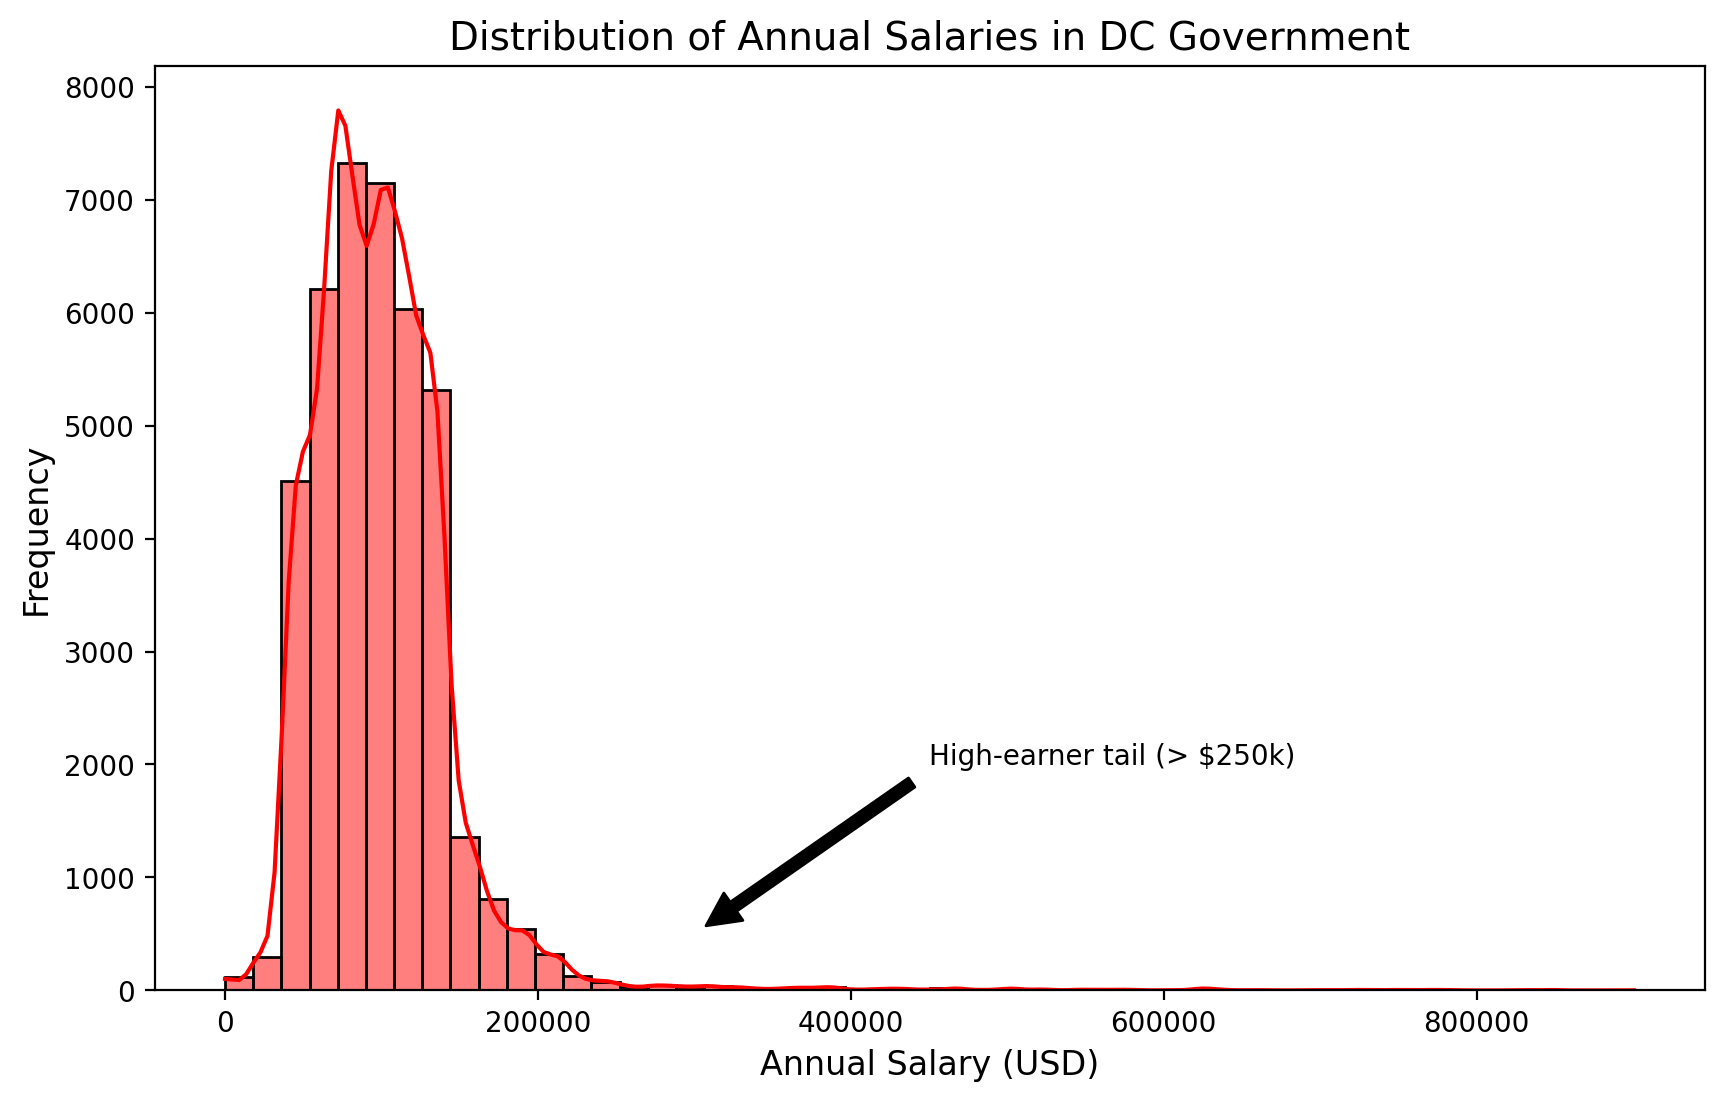

In [36]:
# Annual Salary Histogram
plt.figure(figsize=(10, 6))
sns.histplot(capital_filtered['ANNUAL SALARY'], bins=50, kde=True, color='red')
plt.title('Distribution of Annual Salaries in DC Government', fontsize=14)
plt.xlabel('Annual Salary (USD)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.annotate('High-earner tail (> $250k)', xy=(300000, 500), xytext=(450000, 2000),
             arrowprops=dict(facecolor='black', shrink=0.05), fontsize=10)
plt.tight_layout
plt.savefig('Graphs/univariate_income_hist.jpg')
plt.show()

### This histogram is designed to show the overall distribution of annual salaries across the entire workforce to identify the central tendency and the extent of high-salary outliers. The data shows a right-skewed distribution. While the bulk of the workforce earns between $70,000 and $120,000, there is a distinct "long tail" of high earners stretching toward $900,000. The density peak around $95,000 suggests a strong concentration of middle-management and professional-level roles.

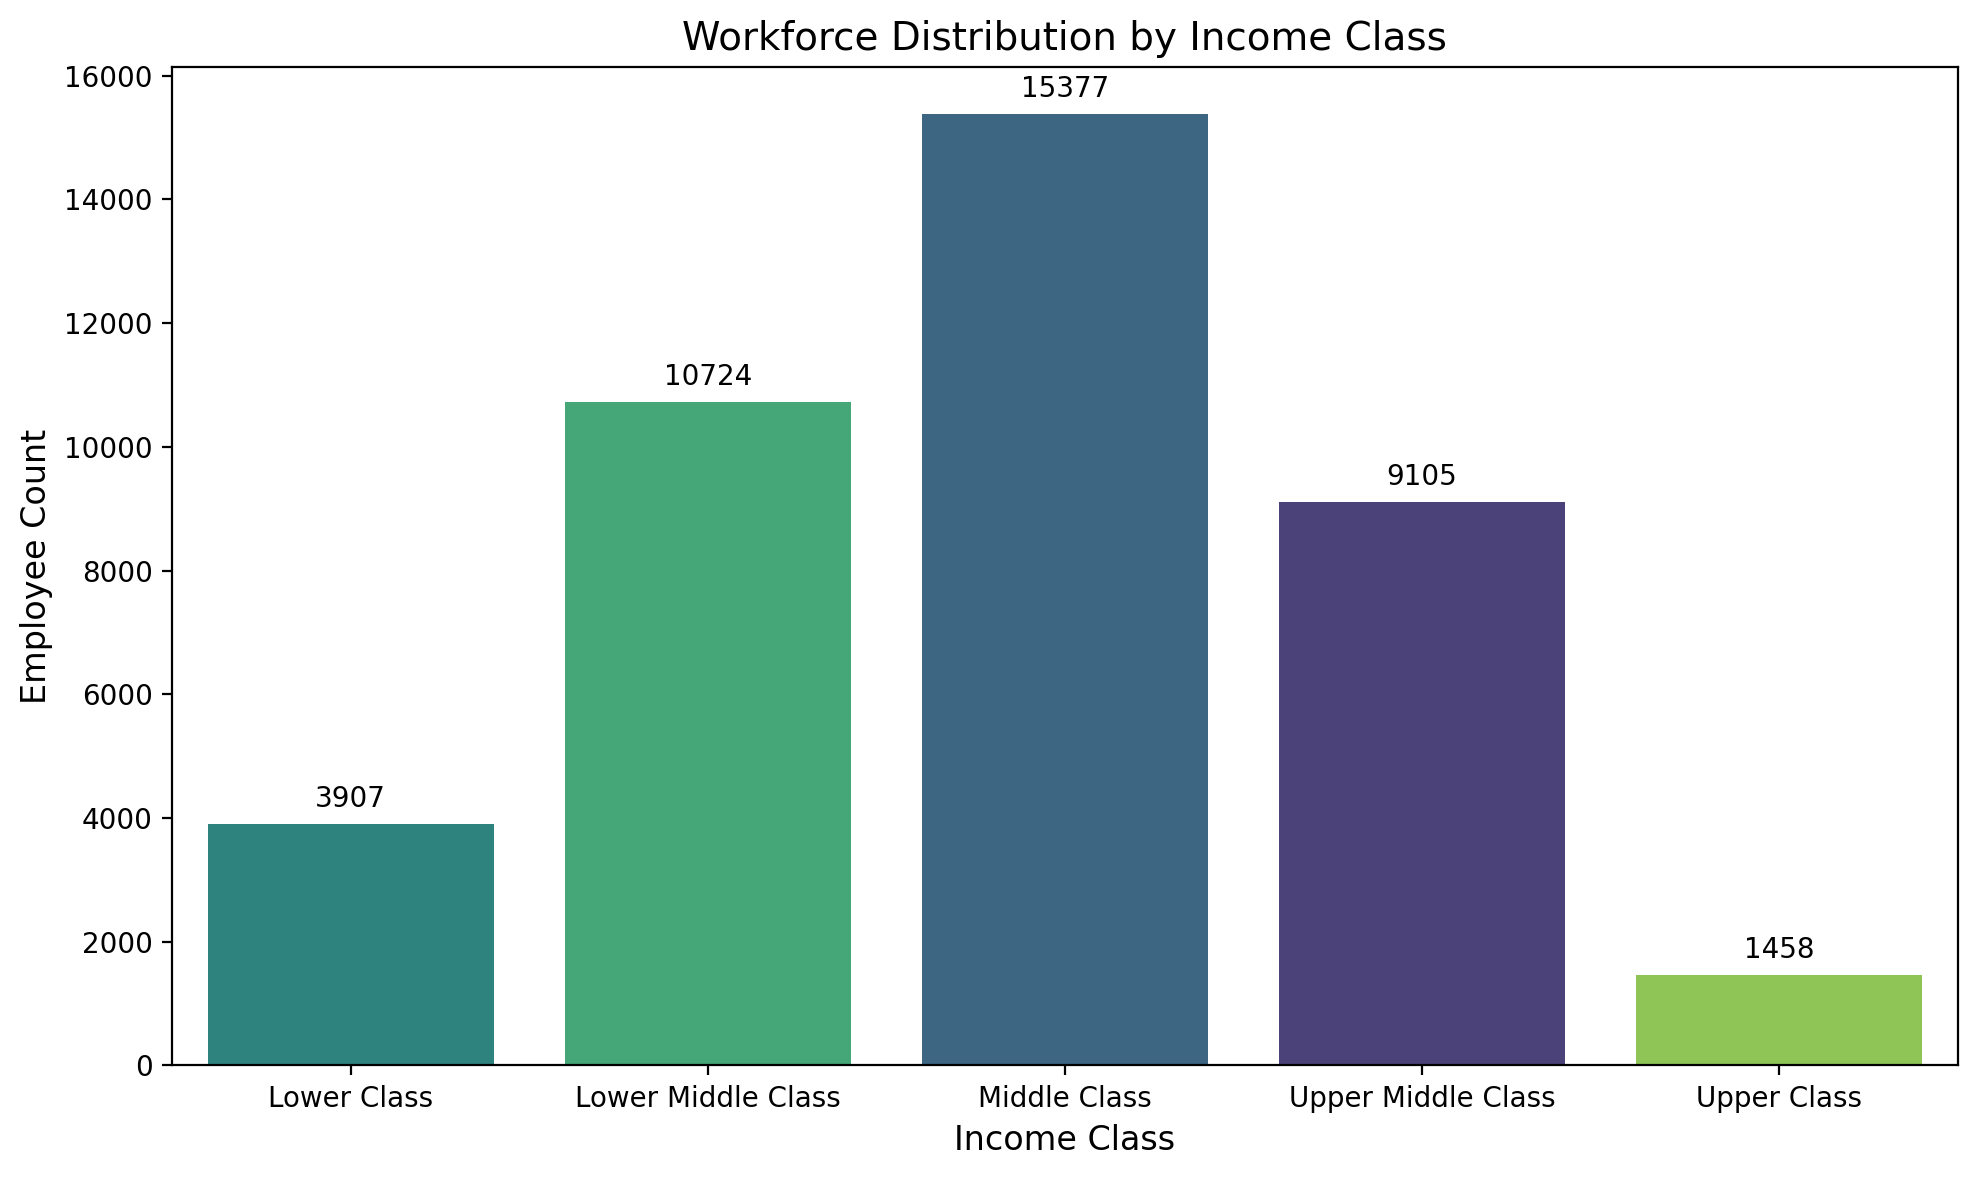

In [37]:
# Workforce Socioeconomic Bar Chart
income_order = ['Lower Class', 'Lower Middle Class', 'Middle Class', 
                'Upper Middle Class', 'Upper Class']
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=capital_filtered, x='INCOME CLASS', order=income_order, hue='INCOME CLASS', palette='viridis')
plt.title('Workforce Distribution by Income Class', fontsize=14)
plt.xlabel('Income Class', fontsize=12)
plt.ylabel('Employee Count', fontsize=12)
plt.xticks(rotation=0)
# Adding data labebls on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 9), textcoords='offset points')
plt.tight_layout()
plt.savefig('Graphs/univariate_class_bar.jpg')
plt.show()

### This bar chart visualizes the distribution of employees among the five predefined income classes to understand which socioeconomic group dominates the DC government. The "Middle Class" is the largest single group in the DC government, followed closely by the "Lower Middle Class." Together, these groups form the backbone of the city's civil service. The relatively small "Upper Class" count indicates that while high salaries exist (as seen in Plot 1), they are reserved for a small elite percentage of the workforce.

/tmp/ipykernel_368/2321682507.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=capital_filtered[capital_filtered['GVT_TYPE_OF_APPT'].isin(top_appts)],


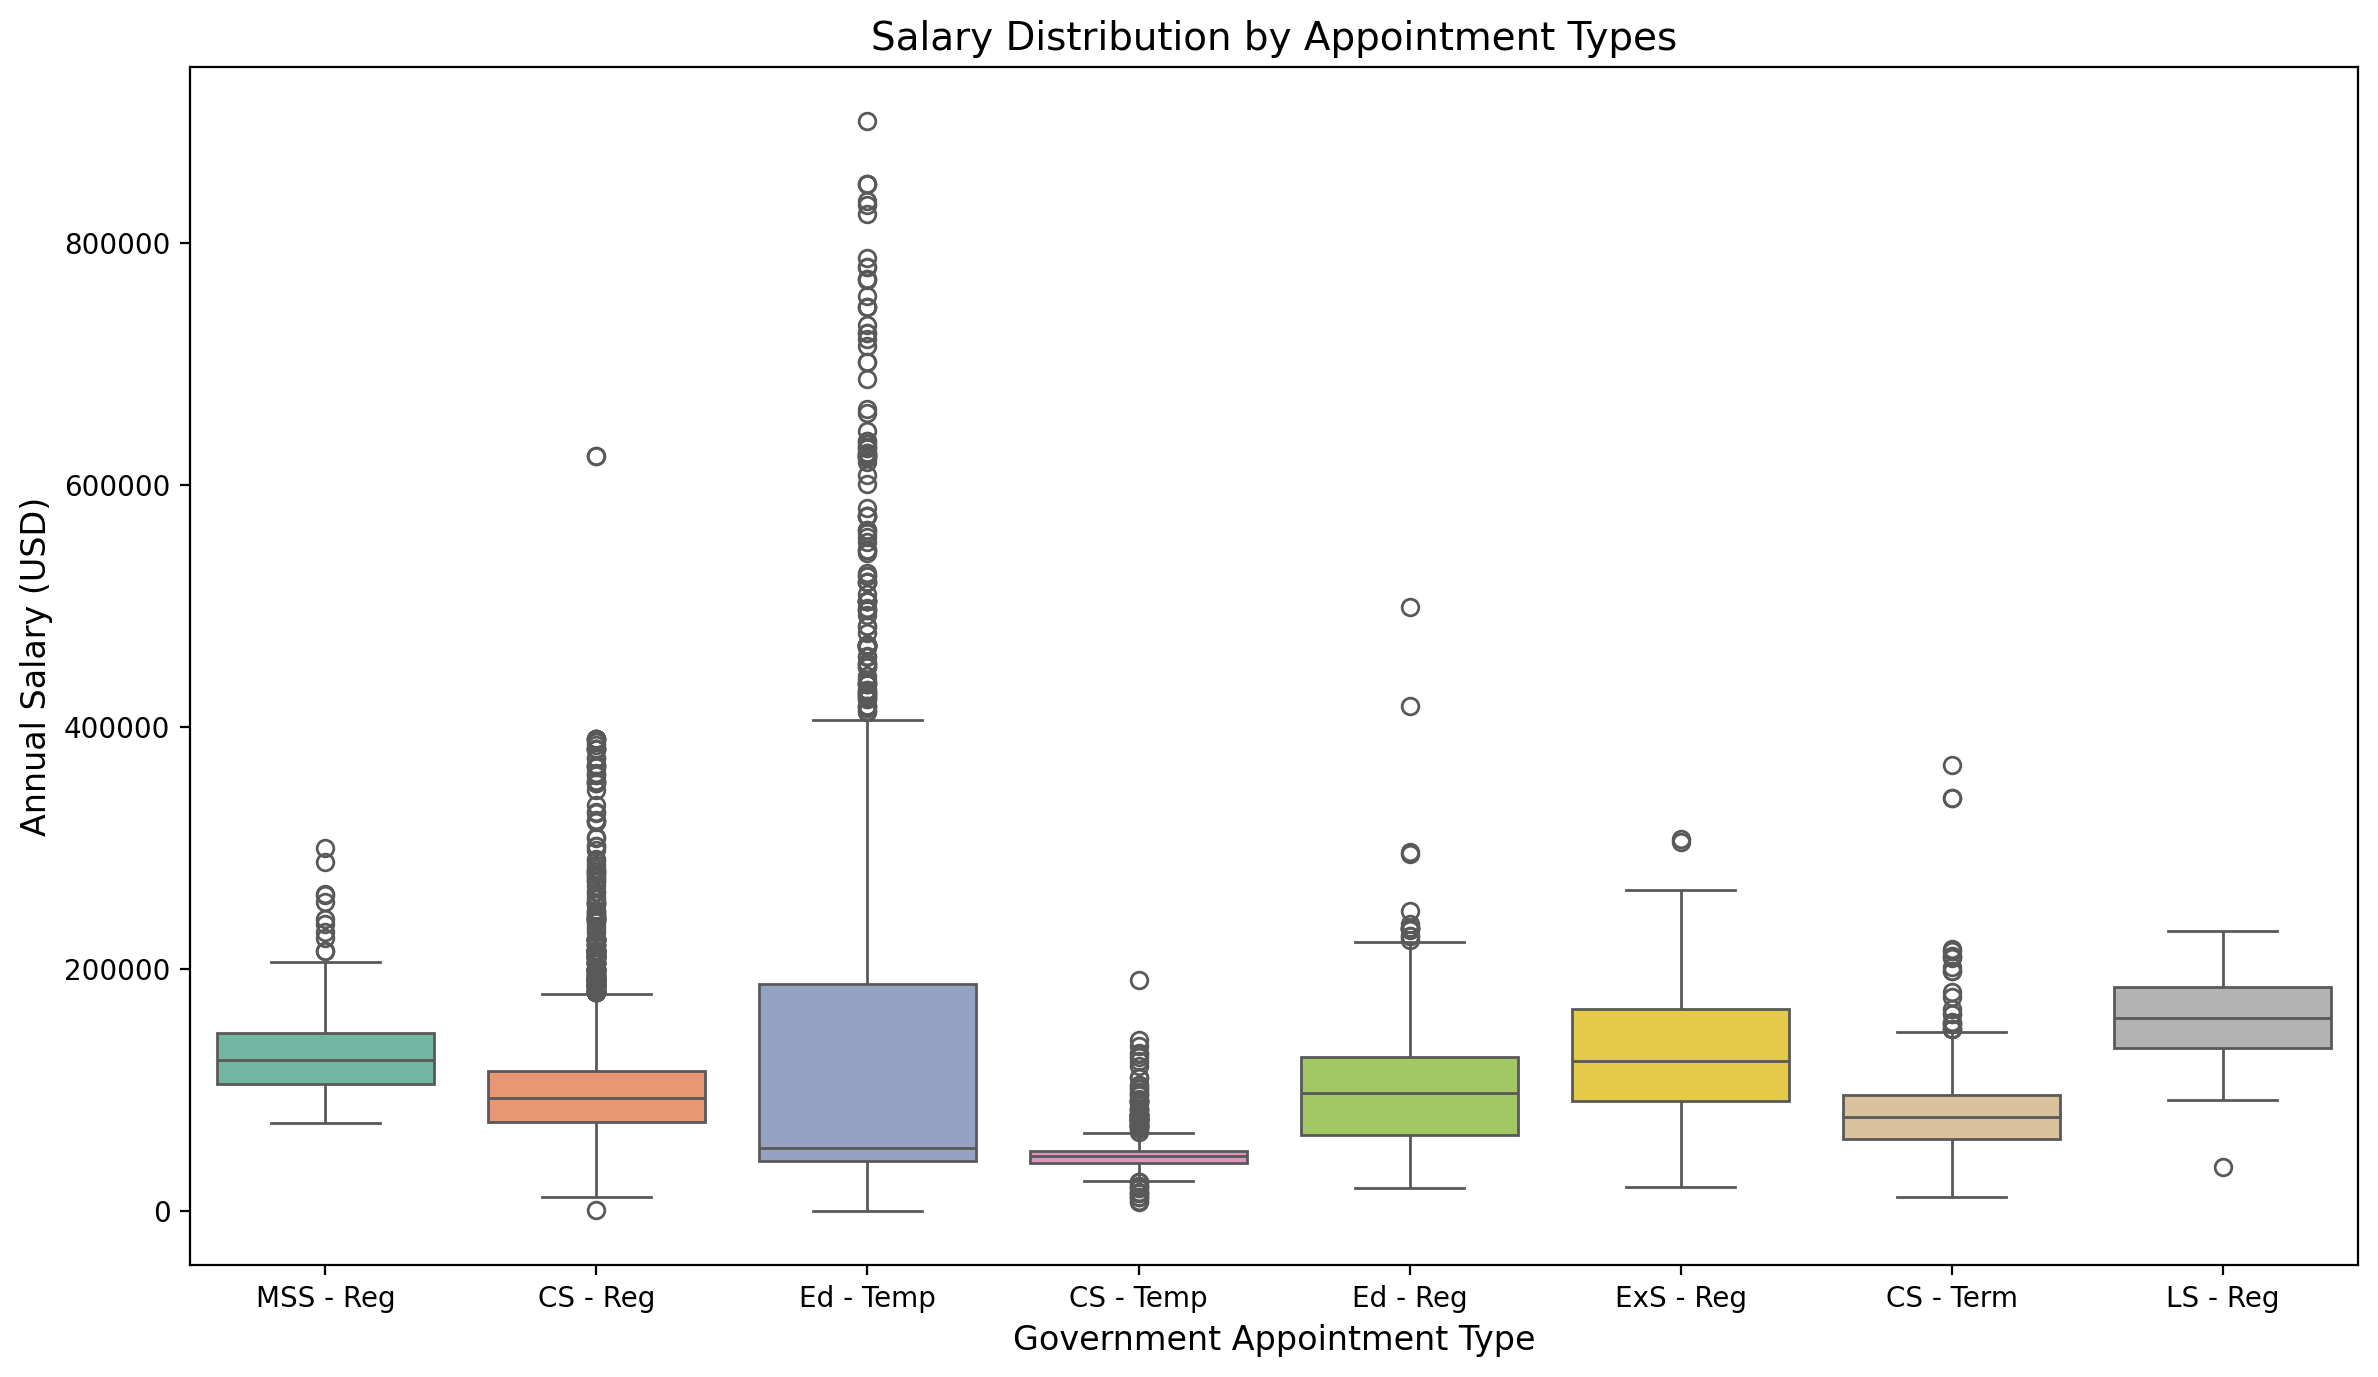

In [38]:
# Salary Distribution by Appointment Type
plt.figure(figsize=(12, 7))
# Filtering for the most frequent appointment types for clarity
top_appts = capital_filtered['GVT_TYPE_OF_APPT'].value_counts().head(8).index
sns.boxplot(data=capital_filtered[capital_filtered['GVT_TYPE_OF_APPT'].isin(top_appts)], 
            x='GVT_TYPE_OF_APPT', y='ANNUAL SALARY', palette='Set2')
plt.title('Salary Distribution by Appointment Types', fontsize=14)
plt.xlabel('Government Appointment Type', fontsize=12)
plt.ylabel('Annual Salary (USD)', fontsize=12)
plt.xticks(rotation=0)
plt.savefig('Graphs/bivariate_salary_appt_box.jpg')
plt.tight_layout()

### This box plot compares the salary ranges across different government appointment types to see if job security (Regular vs. Term) correlates with higher pay. Regular Career Service (CS - Reg) and Management (MSS - Reg) show consistent, stable pay ranges. Notably, "Educational - Regular" (Ed - Reg) roles have a higher median than standard career roles, reflecting the District's investment in teachers. Temporary roles show wider variance, likely due to specialized high-pay consultants vs. low-pay seasonal workers.

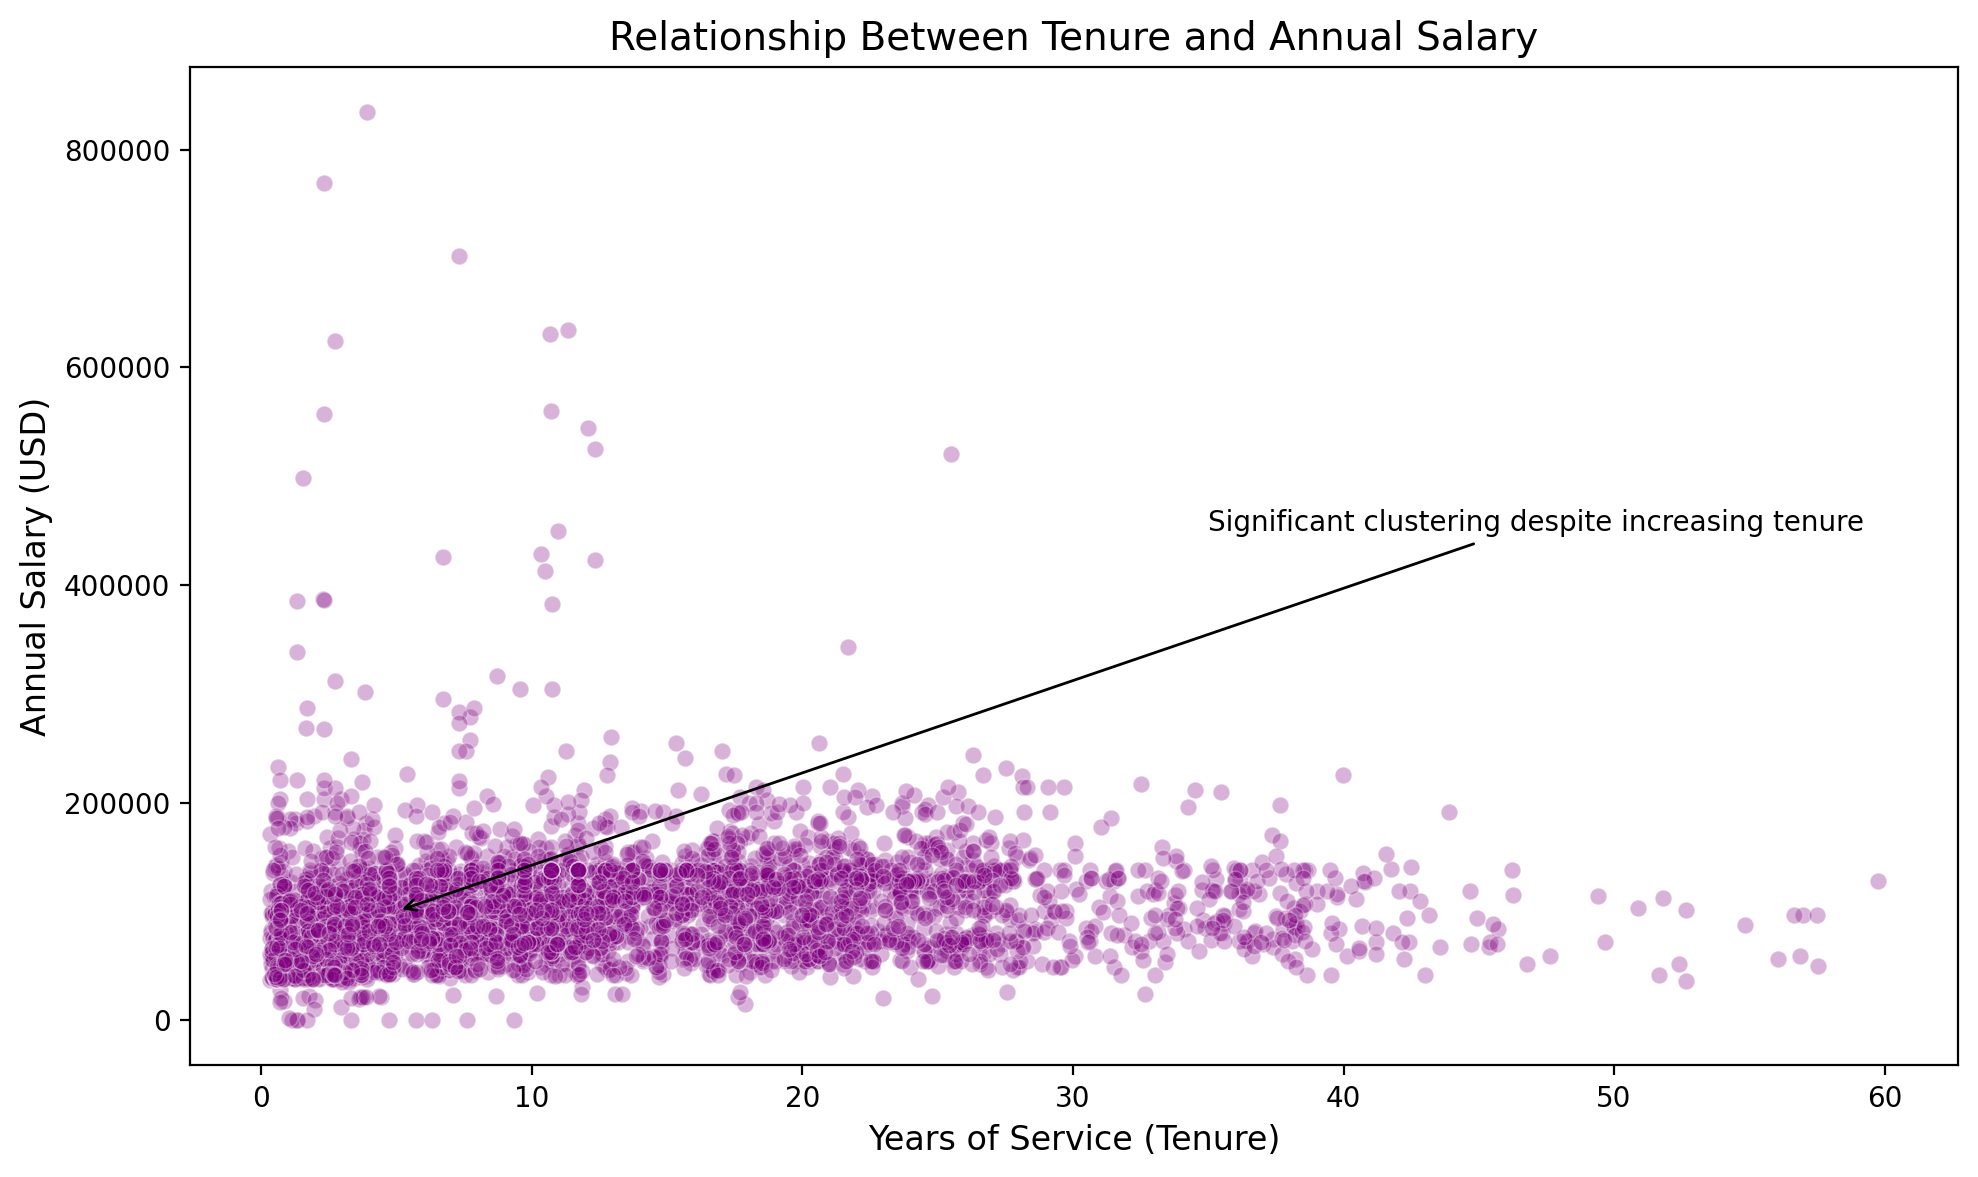

In [39]:
# Tenure vs. Salary Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=capital_filtered.sample(5000), x='TENURE', y='ANNUAL SALARY', alpha=0.3, color='purple')
plt.title('Relationship Between Tenure and Annual Salary', fontsize=14)
plt.xlabel('Years of Service (Tenure)', fontsize=12)
plt.ylabel('Annual Salary (USD)', fontsize=12)
plt.annotate('Significant clustering despite increasing tenure', xy=(5, 100000), xytext=(35, 450000),
             arrowprops=dict(arrowstyle="->", connectionstyle="arc3"), fontsize=10)
plt.tight_layout()
plt.savefig('Graphs/bivariate_tenure_salary_scatter.jpg')
plt.show()

### This scatter plot investigates the relationship between years of service (Tenure) and Annual Salary to detect signs of salary compression. The horizontal clustering suggests significant salary compression. While many employees have 20–40 years of experience, their salaries often remain in the same $80k–$140k band as employees with only 5–10 years of experience. The lack of a steep upward "slope" suggests that longevity does not guarantee exponential salary growth.

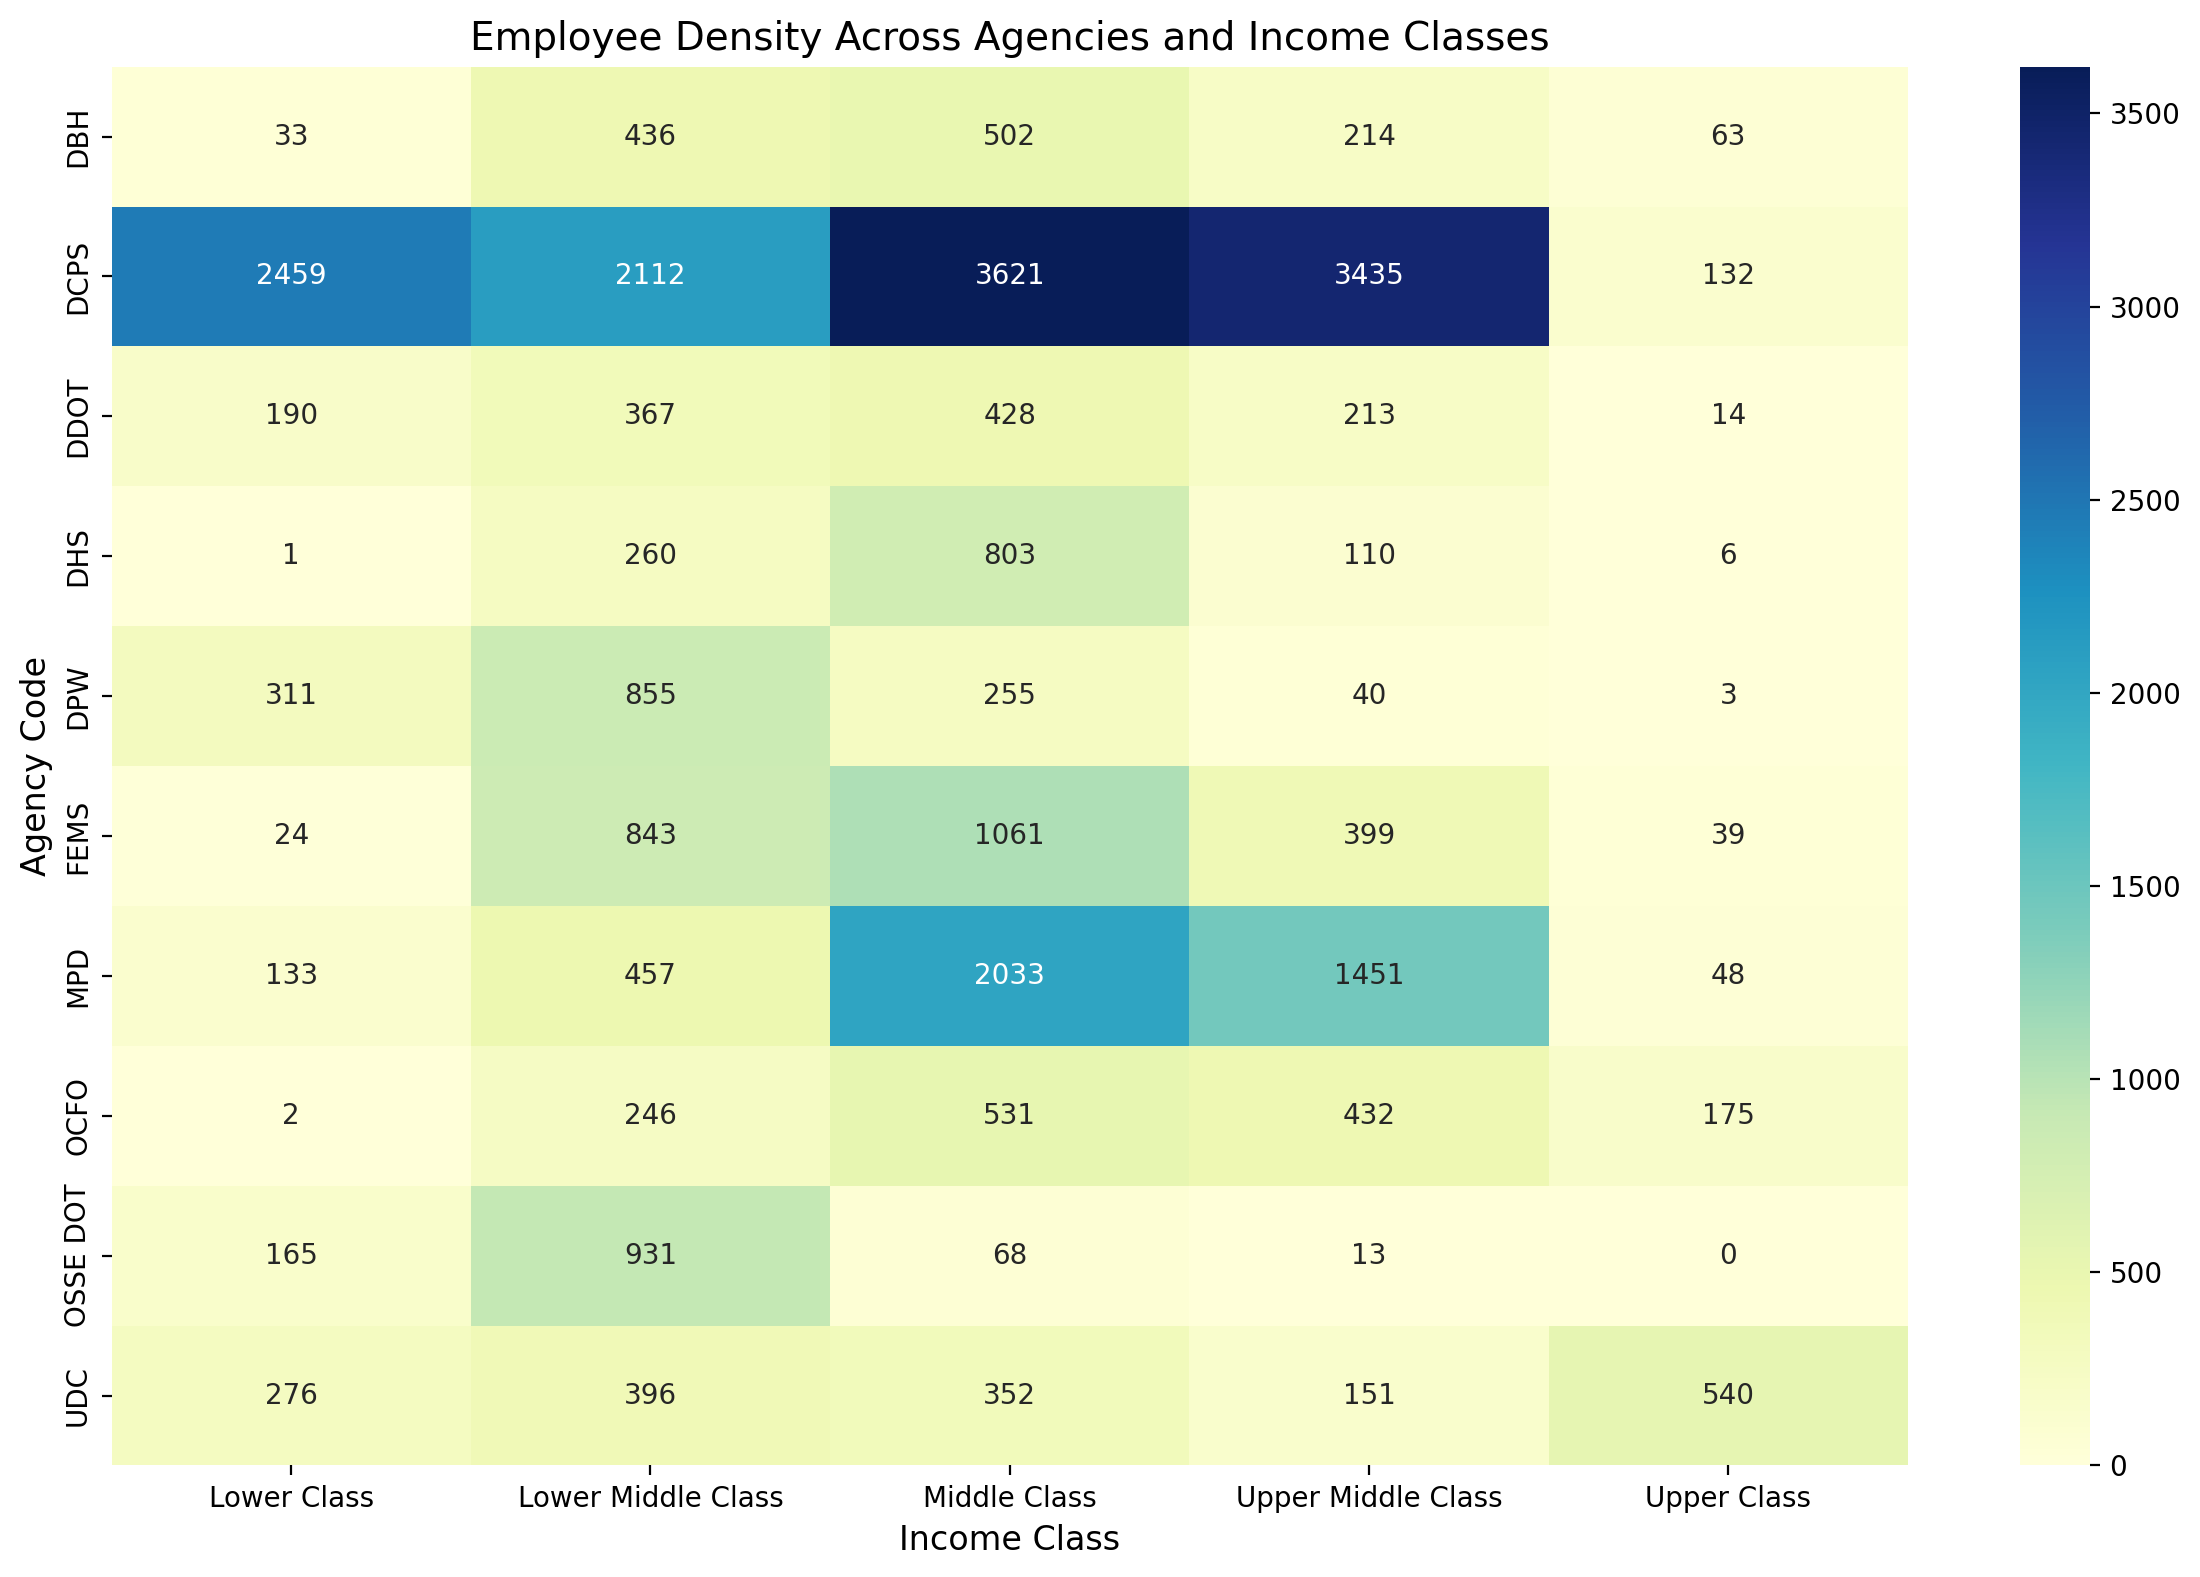

In [40]:
# Agency-Class Density Heatmap (Multivariate)
plt.figure(figsize=(12, 8))
top_10_agencies = capital_filtered['AGENCY'].value_counts().head(10).index
pivot_data = capital_filtered[capital_filtered['AGENCY'].isin(top_10_agencies)].pivot_table(
    index='AGENCY', columns='INCOME CLASS', values='ANNUAL SALARY', aggfunc='count', fill_value=0
)
pivot_data = pivot_data[income_order] # Ensuring class order is logical
sns.heatmap(pivot_data, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Employee Density Across Agencies and Income Classes', fontsize=14)
plt.xlabel('Income Class', fontsize=12)
plt.ylabel('Agency Code', fontsize=12)
plt.tight_layout()
plt.savefig('Graphs/multivariate_agency_class_heatmap.jpg')
plt.show()

### This heatmap identifies which major agencies are most "top-heavy" or "bottom-heavy" by mapping employee counts across agencies and income tiers. DCPS is massive, with thousands in the Lower Middle and Middle classes. In contrast, agencies like the MPD (Police) have a very high concentration in the "Middle" and "Upper Middle" classes, indicating a more upwardly mobile pay structure for public safety compared to education or public works.

In [41]:
# Interactive Salary Box Plot (Plotly) ---
top_agencies = capital_filtered['AGENCY'].value_counts().head(12).index
fig_plotly = px.box(capital_filtered[capital_filtered['AGENCY'].isin(top_agencies)], 
             x='AGENCY', y='ANNUAL SALARY', color='AGENCY',
             title='Salary Ranges for Major DC Government Agencies',
             labels={'ANNUAL SALARY': 'Annual Salary ($)', 'AGENCY': 'Agency Code'},
             hover_data=['JOBTITLE', 'GVT_TYPE_OF_APPT'])
fig_plotly.update_layout(xaxis_tickangle=-45)
fig_plotly.write_html('Graphs/interactive_agency_box.html')
fig_plotly.show()

### This interactive box plot allows for a detailed comparison of pay scales across the top 12 agencies, with hover-data providing context on specific job titles. By hovering over the outliers in this interactive chart, users can see that high-earners are often specialized roles like "Medical Officer" or "Agency Director." It highlights that UDC and MPD have significantly higher "ceilings" than agencies like the Department of Human Services (DHS).

In [42]:
sample_alt = capital_filtered.sample(3000)
chart = alt.Chart(sample_alt).mark_circle(size=60).encode(
    x=alt.X('TENURE:Q', title='Years of Tenure'),
    y=alt.Y('ANNUAL SALARY:Q', title='Annual Salary (USD)'),
    color=alt.Color('INCOME CLASS:N', sort=income_order, legend=alt.Legend(title="Socioeconomic Class")),
    tooltip=['FIRST_NAME', 'LAST_NAME', 'JOBTITLE', 'AGENCY', 'ANNUAL SALARY', 'TENURE']
).properties(
    title='Employee Tenure vs. Salary Levels',
    width=600, height=400
).interactive()
chart.save('Graphs/interactive_tenure_salary.html')
chart.show()

alt.Chart(...)

### his interactive scatter plot maps tenure against salary, allowing users to hover over individual data points to see the specific person (anonymized) and their role. This tool allows for granular exploration of "The Veterans." Users can filter by color to see how long it takes for a "Lower Middle Class" employee to transition into the "Upper Middle Class" (if they ever do). It emphasizes the "Professional Class" plateau where most employees spend their entire careers.

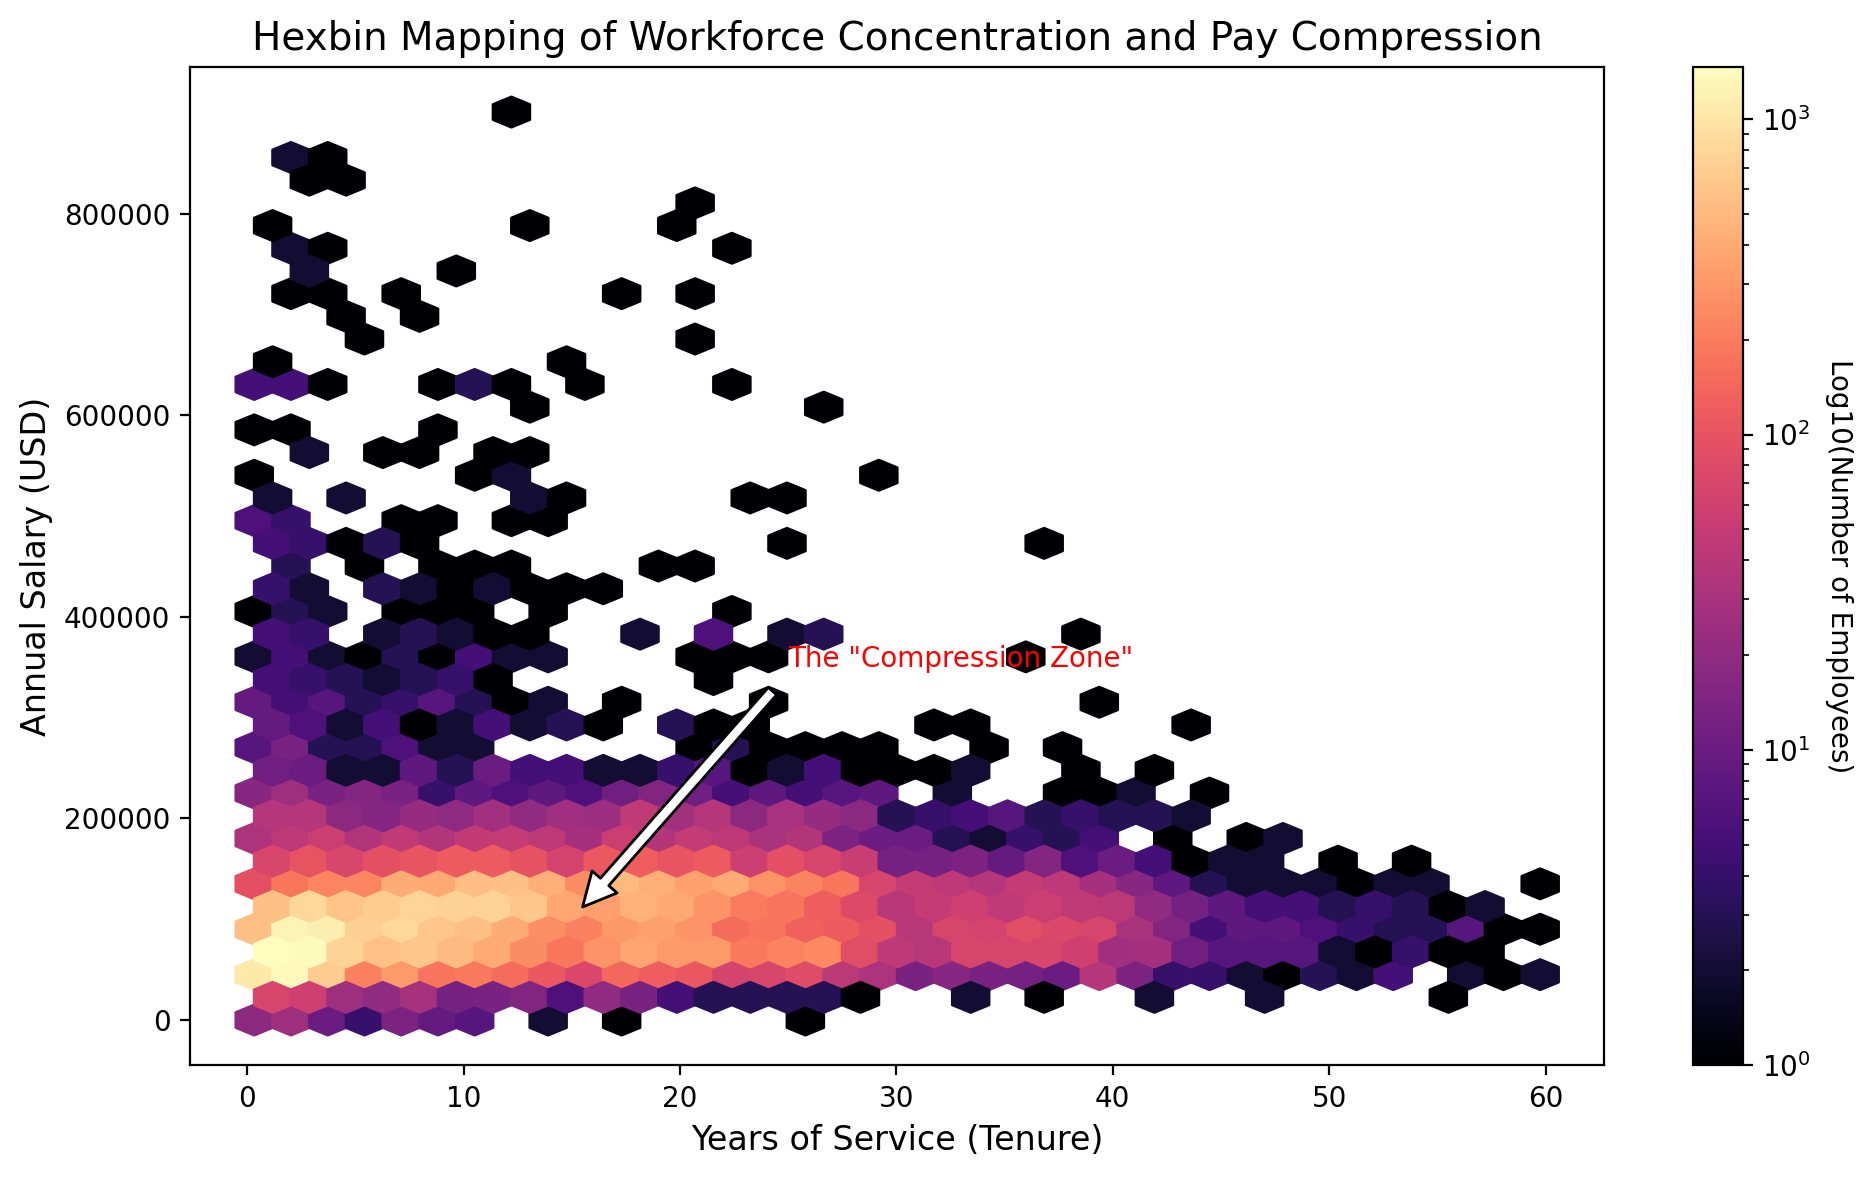

In [43]:
# The Salary Compression Heatmap (Hexbin)
plt.figure(figsize=(10, 6))
# Using log bins to manage the massive density at lower tenures
hb = plt.hexbin(capital_filtered['TENURE'], capital_filtered['ANNUAL SALARY'], gridsize=35, cmap='magma', bins='log')
cb = plt.colorbar(hb)
cb.set_label('Log10(Number of Employees)', rotation=270, labelpad=15)
plt.title('Hexbin Mapping of Workforce Concentration and Pay Compression', fontsize=14)
plt.xlabel('Years of Service (Tenure)', fontsize=12)
plt.ylabel('Annual Salary (USD)', fontsize=12)
plt.annotate('The "Compression Zone"', xy=(15, 100000), xytext=(25, 350000),
             color='red', arrowprops=dict(facecolor='white', shrink=0.05), fontsize=10)
plt.tight_layout()
plt.savefig('Graphs/hexbin.jpg')
plt.show()

### This hexbin plot surfaces a hidden insight: the exact "Compression Zone" where the vast majority of DC’s long-term workforce is stuck. Unlike a standard scatter plot, the hexbin shows the sheer density of the workforce. The intense "hot spot" between 5 and 15 years of tenure in the $90k range reveals a massive bottleneck. The vertical "spread" does not increase significantly with tenure, proving that the District's pay structure is designed to reward entry and mid-level service, but often stalls for long-term civil servants.

# ***Additional Analysis/Findings***

/tmp/ipykernel_368/354027784.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=appt_comp, x='Category', y='ANNUAL SALARY', palette='muted', inner="quartile")


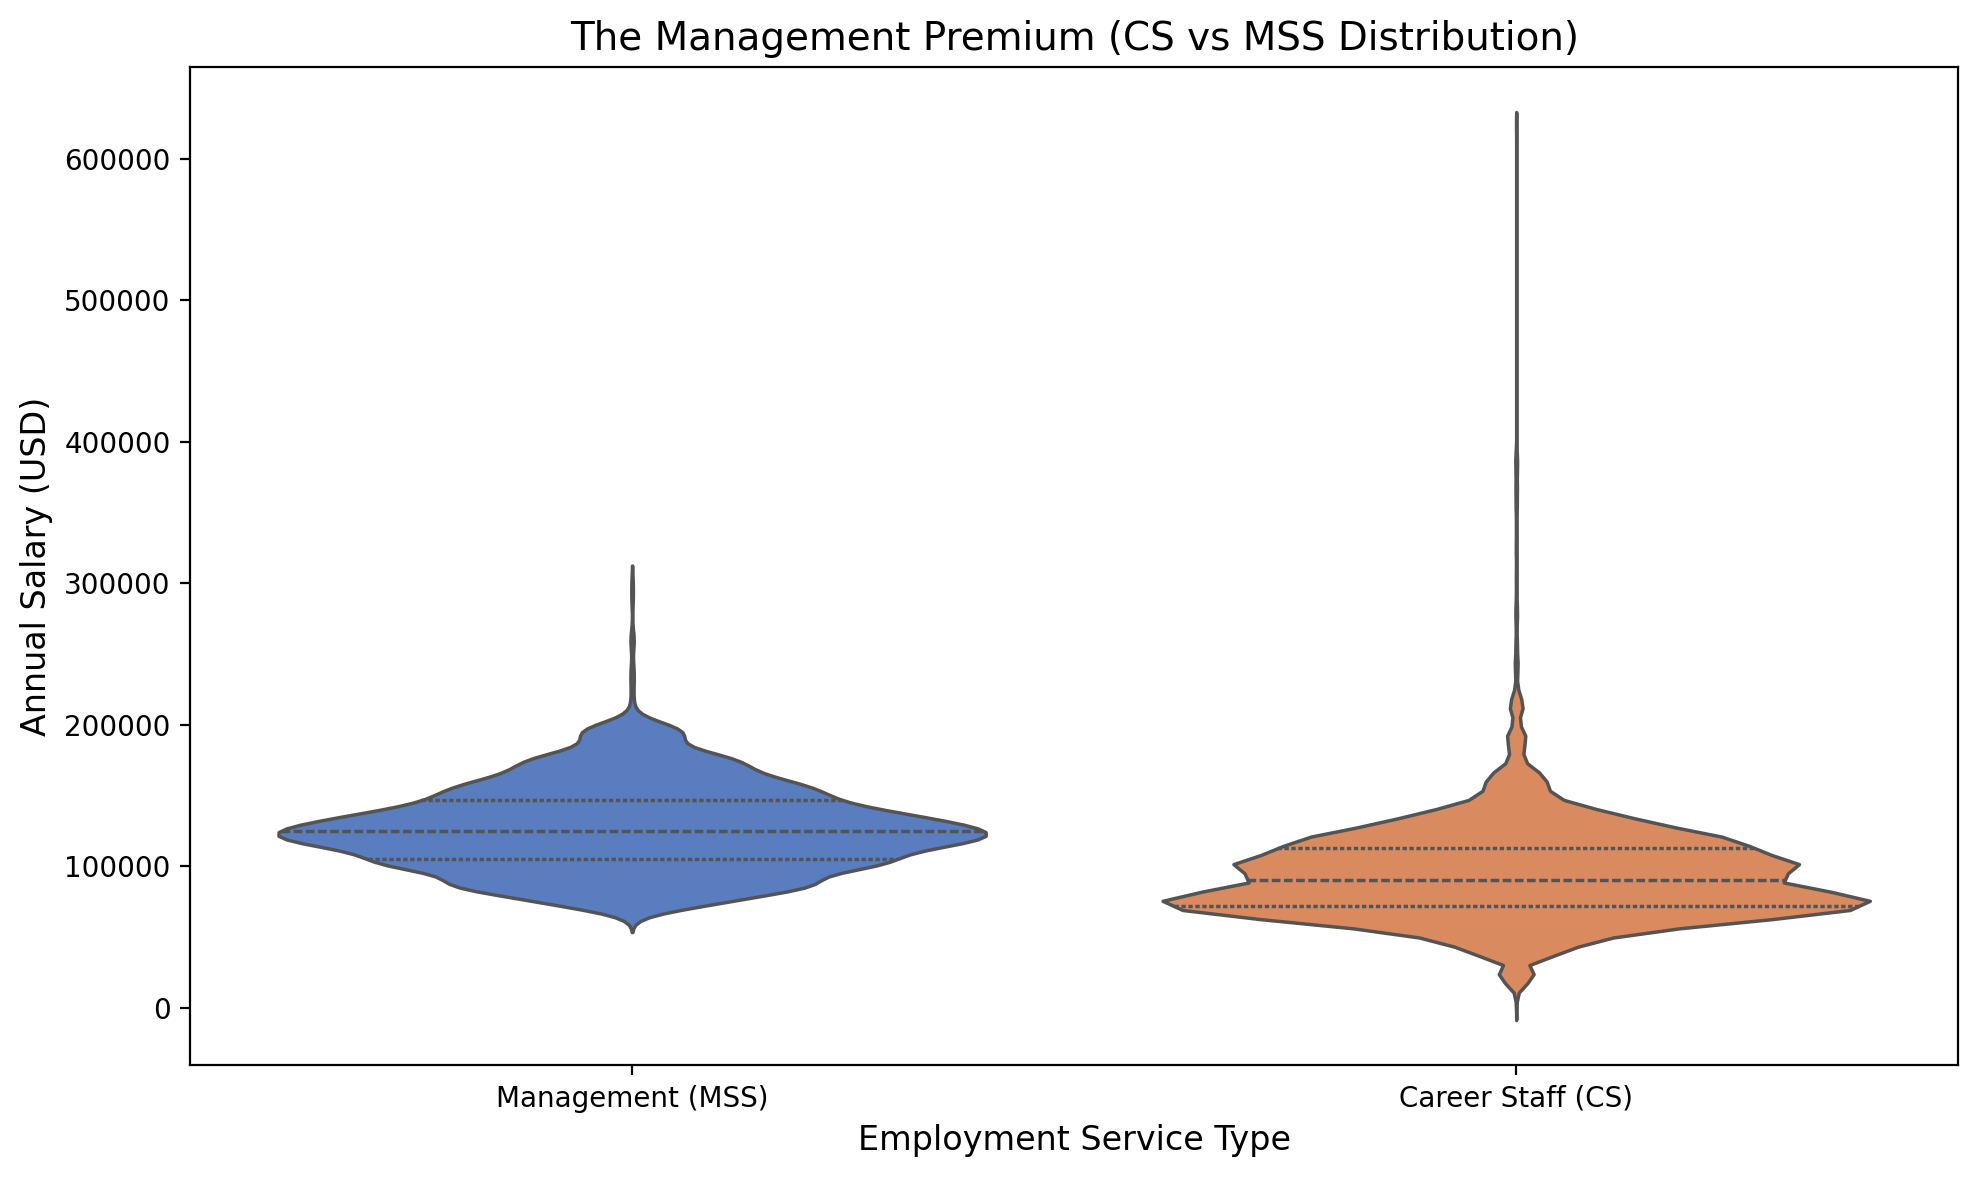

In [44]:
plt.figure(figsize=(10, 6))

# Filter for Career Service (CS) and Management Supervisory Service (MSS)
# This removes temporary, educational, and executive service for a direct comparison
appt_comp = capital_filtered[capital_filtered['GVT_TYPE_OF_APPT'].str.contains('CS|MSS', na=False)].copy()

# Simplify labels for the visualization
appt_comp['Category'] = appt_comp['GVT_TYPE_OF_APPT'].apply(
    lambda x: 'Management (MSS)' if 'MSS' in x else 'Career Staff (CS)'
)

# Using a violin plot to show both the range and the density of salaries
sns.violinplot(data=appt_comp, x='Category', y='ANNUAL SALARY', palette='muted', inner="quartile")

plt.title('The Management Premium (CS vs MSS Distribution)', fontsize=14)
plt.xlabel('Employment Service Type', fontsize=12)
plt.ylabel('Annual Salary (USD)', fontsize=12)
plt.tight_layout()
plt.savefig('Graphs/management_premium')
plt.show()

### One of the most significant barriers to socioeconomic mobility is the transition from "worker" to "supervisor." This analysis compares the salary distributions of Career Service (CS) employees against the Management Supervisory Service (MSS) to quantify the financial "premium" associated with moving into a management role. The violin plot reveals a clear upward shift in compensation for Management (MSS) roles. While the bulk of Career Staff (CS) earns in the $70k–$100k range, the MSS distribution is much more concentrated at the $130k–$160k level. Furthermore, the MSS distribution is "thinner" at the bottom, indicating a high salary floor for managers. This finding highlights that management status is a primary gatekeeper for entry into the "Upper Middle Class" and "Upper Class" income tiers.

/tmp/ipykernel_368/3915160160.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly_avg, x='HIRE_MONTH', y='ANNUAL SALARY', palette='coolwarm')


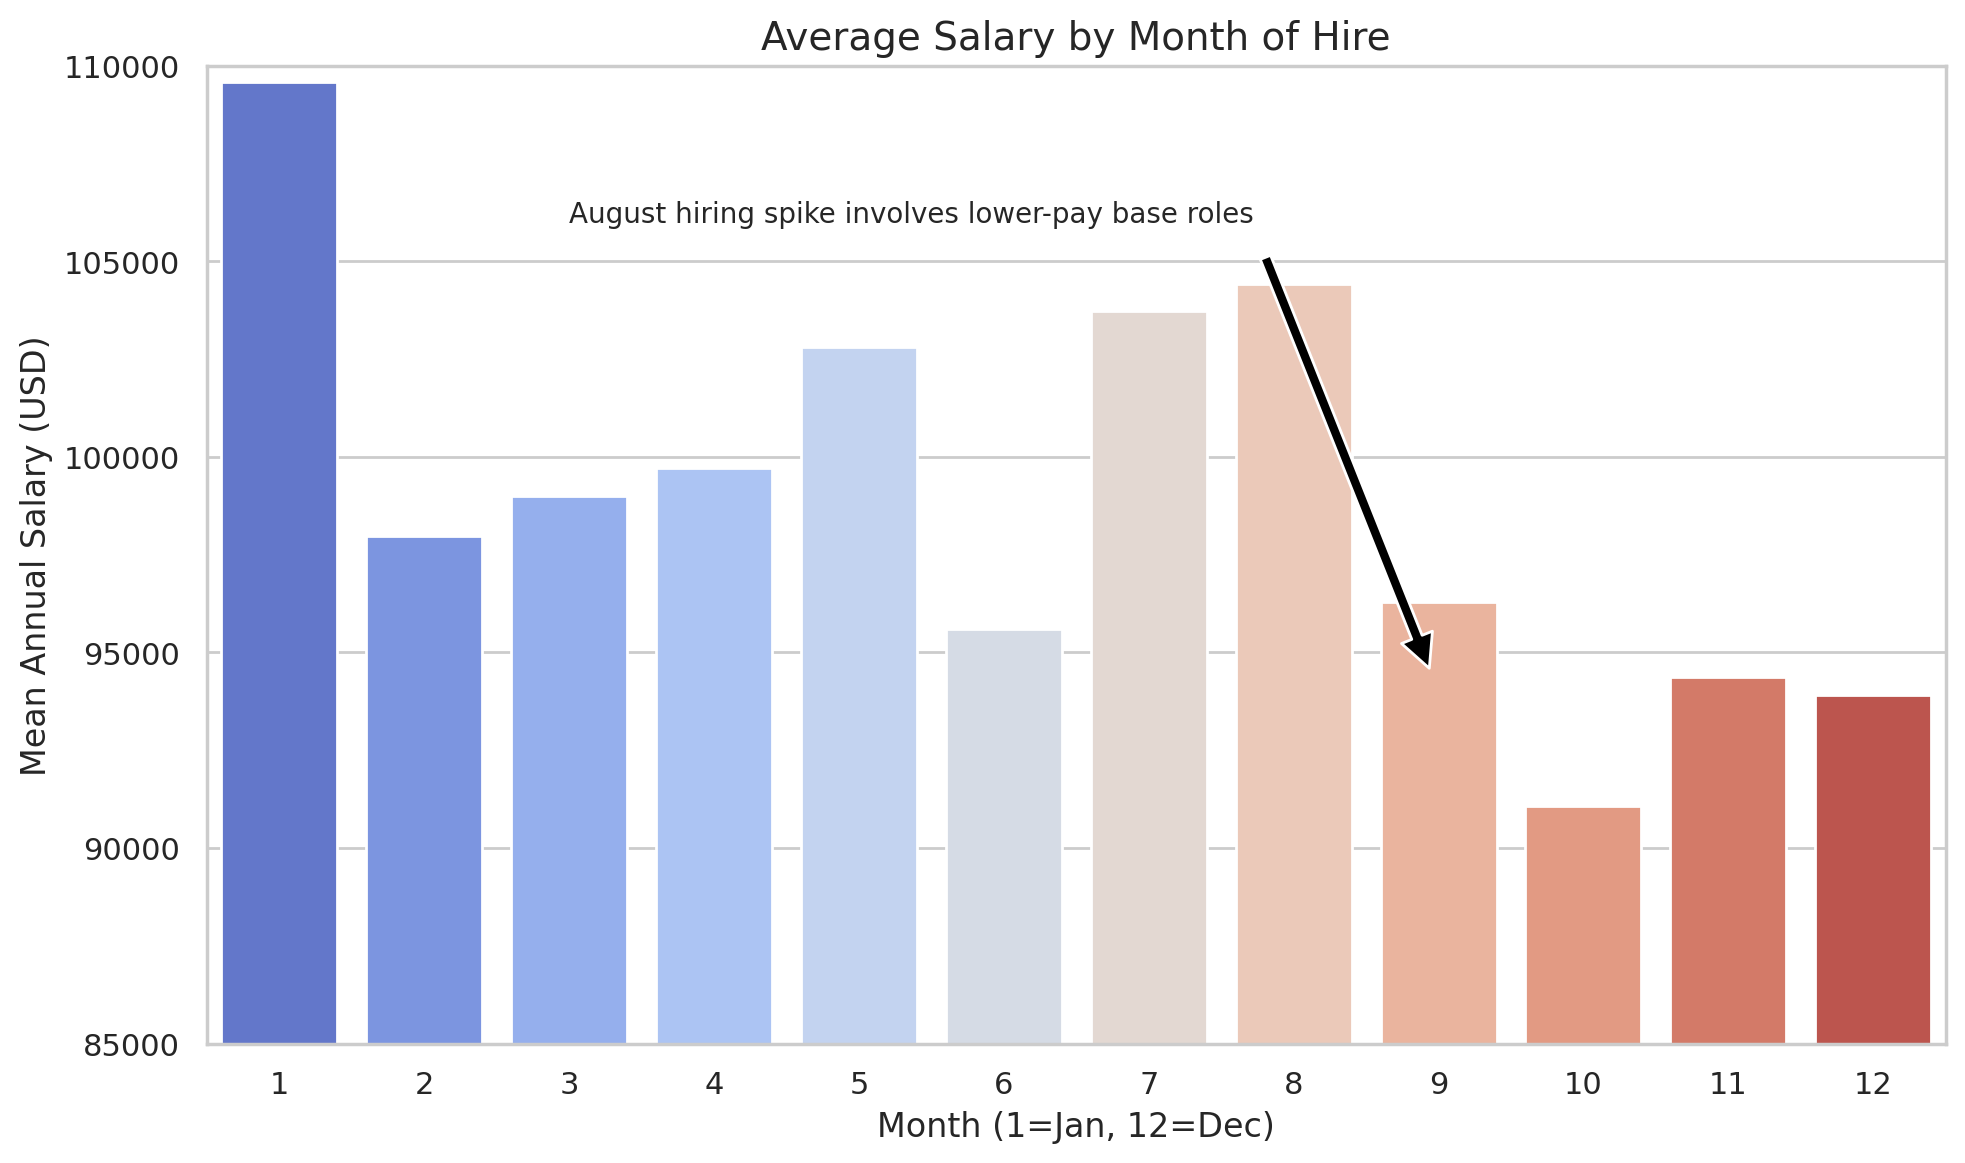

In [45]:
capital_filtered['HIRE_MONTH'] = capital_filtered['HIREDATE'].dt.month

sns.set_theme(style="whitegrid")

# Additional Analysis 1: The August Anomaly (Seasonality vs Pay)
plt.figure(figsize=(10, 6))

# Calculate average salary by hire month to see if mass-hiring months pay less
monthly_avg = capital_filtered.groupby('HIRE_MONTH')['ANNUAL SALARY'].mean().reset_index()

sns.barplot(data=monthly_avg, x='HIRE_MONTH', y='ANNUAL SALARY', palette='coolwarm')

plt.title('Average Salary by Month of Hire', fontsize=14)
plt.xlabel('Month (1=Jan, 12=Dec)', fontsize=12)
plt.ylabel('Mean Annual Salary (USD)', fontsize=12)

# Zooming in on the Y-axis to highlight the variance
plt.ylim(85000, 110000) 

plt.annotate('August hiring spike involves lower-pay base roles', 
             xy=(8, 94000), xytext=(2, 106000),
             arrowprops=dict(facecolor='black', shrink=0.05), fontsize=10)

plt.tight_layout()
plt.savefig('Graphs/seaonality.jpg')
plt.show()

### During the initial data exploration, a massive spike in hiring was observed in August. The motivation for this analysis was to determine if this high-volume hiring period (largely driven by the academic year for DCPS and UDC) correlates with lower average starting salaries compared to "off-peak" hiring months like January or April. The visualization confirms that employees hired in August have a lower average annual salary (~$94,000) compared to those hired in January or February (~$104,000). This suggests that the District’s seasonal hiring surge is primarily composed of entry-level or base-pay roles (such as teachers and school support staff), whereas specialized administrative or high-level technical roles are filled more consistently throughout the winter and spring months.

# Insights and Conclusion
### This systematic investigation into the District of Columbia’s public workforce reveals a robust "diamond-shaped" socioeconomic structure, where the Middle Class serves as the primary organizational anchor rather than the hollowed-out distributions often seen in the private sector. A defining characteristic of this workforce is its seasonal "August Anomaly," where mass-hiring for educational roles creates a predictable influx of base-pay positions that contrast with the more stable, high-pay hiring cycles observed in the spring. Centrally, the analysis of salary compression through multivariate hexbin mapping demonstrates that while longevity secures an employee’s place within the middle-income tiers, Tenure alone acts as a weak catalyst for significant economic mobility. Instead, the "Management Premium" serves as the functional gatekeeper; the transition to Management Supervisory Service (MSS) status provides a significantly higher salary floor and remains the most viable path into the Upper Middle and Upper Class brackets. While these findings are compelling, the study is limited by the exclusion of non-salary benefits and the mathematical noise generated by annualized adjunct faculty rates. Consequently, future research should leverage longitudinal tracking to map the precise velocity of career promotions and incorporate geospatial data to analyze how these compensation patterns influence the broader urban landscape of the District.